In [1]:
import pandas as pd
import numpy as np
import ast

# load dataset

## cloud

In [2]:
folder_path = "../cloud/split_data"

In [3]:
import os
# Debugging: Print the list of CSV files found in the directory
file_list = []
for root, dirs, files in os.walk(folder_path):
    file_list.extend([os.path.join(root, file) for file in files if file.endswith('.csv')])

# Print the list of files found
print(file_list)

['/Volumes/Axiller-MacBook/axiler_dell_backup/AXILER/cloud-device-troubleshooting--qa-research/dataset_preprocessing/data/cloud/filter-data/cloud_test.csv', '/Volumes/Axiller-MacBook/axiler_dell_backup/AXILER/cloud-device-troubleshooting--qa-research/dataset_preprocessing/data/cloud/filter-data/cloud_train.csv', '/Volumes/Axiller-MacBook/axiler_dell_backup/AXILER/cloud-device-troubleshooting--qa-research/dataset_preprocessing/data/cloud/filter-data/cloud_val.csv']


In [4]:
path = "../cloud/split_data"

cloud_multimodal_train = pd.read_excel(os.path.join(path, "cloud_train.xlsx"))
cloud_multimodal_test = pd.read_excel(os.path.join(path, "cloud_test.xlsx"))
cloud_multimodal_val = pd.read_excel(os.path.join(path, "cloud_val.xlsx"))


In [9]:
cloud_multimodal_val.shape

(1484, 13)

## Qa setup

#### Preprocessed

In [10]:
# filter columns
cols = ['title', 'body', 'selected_answer', 'images']

cloud_multimodal_train, cloud_multimodal_test, cloud_multimodal_val = [
    df[cols] for df in (
        cloud_multimodal_train,
        cloud_multimodal_test,
        cloud_multimodal_val
    )
]


In [11]:
# sample
cloud_multimodal_test.head(1)

,title,body,selected_answer,images
0,Some recently changed resources are not yet pu...,\r\n \r\nEvery once in a while ...,"If that happens for whatever reasons, you need...",['https://i.sstatic.net/QQmRh.png']


In [12]:
# add title+body to make context column

for df in (cloud_multimodal_train, cloud_multimodal_test, cloud_multimodal_val):
    df['context'] = (
        "title: "
        + df['title'].astype(str)
        + "\nbody: "
        + df['body'].astype(str).str.strip()
    )


In [13]:
# filterd the processed part
def make_processed(df):
    return df[['context', 'selected_answer', 'images']] \
             .rename(columns={
                 'selected_answer': 'gt',
                 'images': 'img'
             })

cloud_processed_train, cloud_processed_test, cloud_processed_val = [
    make_processed(df) for df in (
        cloud_multimodal_train,
        cloud_multimodal_test,
        cloud_multimodal_val
    )
]

In [14]:
# sample
cloud_processed_train.head(1)

,context,gt,img
0,title: I am using Azure Devops to build and pu...,\r\nWhen using buildAndPush command in Docker ...,['https://i.sstatic.net/D7pQd.png']


## device

In [ ]:
folder_path="/content/drive/MyDrive/scrap/Device/QA/train_test_split/reduced_version/multimodal"

In [ ]:
import os
# Debugging: Print the list of CSV files found in the directory
file_list = []
for root, dirs, files in os.walk(folder_path):
    file_list.extend([os.path.join(root, file) for file in files if file.endswith('.csv')])

# Print the list of files found
print(file_list)

['/content/drive/MyDrive/scrap/Device/QA/train_test_split/reduced_version/multimodal/reduce-train.csv', '/content/drive/MyDrive/scrap/Device/QA/train_test_split/reduced_version/multimodal/reduce-val.csv', '/content/drive/MyDrive/scrap/Device/QA/train_test_split/reduced_version/multimodal/reduce-test.csv', '/content/drive/MyDrive/scrap/Device/QA/train_test_split/reduced_version/multimodal/reduce-latest/multimodal_device_test.csv', '/content/drive/MyDrive/scrap/Device/QA/train_test_split/reduced_version/multimodal/reduce-latest/multimodal_device_val.csv', '/content/drive/MyDrive/scrap/Device/QA/train_test_split/reduced_version/multimodal/reduce-latest/multimodal_device_train.csv']


In [27]:
path = "../cloud/split_data"

device_multimodal_train = pd.read_excel(os.path.join(path, "device_train.xlsx"))
device_multimodal_test = pd.read_excel(os.path.join(path, "device_test.xlsx"))
device_multimodal_val = pd.read_excel(os.path.join(path, "device_val.xlsx"))


In [28]:
device_multimodal_test.shape

(947, 12)

## Qa setup

#### Preprocessed

In [29]:
# filter columns
cols = ['title', 'body', 'selected_answer', 'images']

device_multimodal_train, device_multimodal_test, device_multimodal_val = [
    df[cols] for df in (
        device_multimodal_train,
        device_multimodal_test,
        device_multimodal_val
    )
]


In [30]:
# sample
device_multimodal_test.head(1)

,title,body,selected_answer,images
0,What is the purpose of the INPUT chain in the ...,\r\n \r\nWhat is the purpose of...,\r\nIf some NAT operation needs to be only don...,['https://i.sstatic.net/NUh2k.png']


In [31]:
# add title+body to make context column

for df in (device_multimodal_train, device_multimodal_test, device_multimodal_val):
    df['context'] = (
        "title: "
        + df['title'].astype(str)
        + "\nbody: "
        + df['body'].astype(str).str.strip()
    )


In [32]:
# filterd the processed part
def make_processed(df):
    return df[['context', 'selected_answer', 'images']] \
             .rename(columns={
                 'selected_answer': 'gt',
                 'images': 'img'
             })

device_processed_train, device_processed_test, device_processed_val  = [
    make_processed(df) for df in (
        device_multimodal_train, device_multimodal_test, device_multimodal_val
    )
]

In [33]:
# sample
device_processed_train.head(1)

,context,gt,img
0,title: WireShark Remote Capture failed:NFLOG l...,The error message is explaining what is the ca...,"['https://i.sstatic.net/E1u6R.png', 'https://i..."


# EDA

## Cloud

### *Min*, *Max* and *Avg*

<b><h3> Context Text </h3> </b>

In [34]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [18]:
# tokenize setup
def text_length(text, add_special_tokens=True):
    if pd.isnull(text) or not isinstance(text, str) or not text.strip():
        return 0
    temp_inputs = tokenizer(text, return_tensors="pt", add_special_tokens=add_special_tokens)
    return temp_inputs.input_ids.shape[1]


In [35]:
# apply tokenize
for df in (cloud_processed_train, cloud_processed_test, cloud_processed_val):
    df['context_len'] = df['context'].apply(lambda txt: text_length(txt))

Token indices sequence length is longer than the specified maximum sequence length for this model (2226 > 512). Running this sequence through the model will result in indexing errors


In [21]:
cloud_processed_train.head(1)

,context,gt,img,context_len
0,title: I am using Azure Devops to build and pu...,\r\nWhen using buildAndPush command in Docker ...,['https://i.sstatic.net/D7pQd.png'],186


In [22]:
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    stats = df['context_len'].agg(
        total='count',
        minimum='min',
        maximum='max',
        average='mean',
    )
    print(f"--- CLOUD {name.upper()} SPLIT ---")
    print(stats.to_string())
    print()


--- CLOUD TRAIN SPLIT ---
total       4693.000000
minimum       26.000000
maximum    15193.000000
average      422.466439

--- CLOUD TEST SPLIT ---
total       1568.000000
minimum       37.000000
maximum    11068.000000
average      424.267857

--- CLOUD VAL SPLIT ---
total      1484.000000
minimum      26.000000
maximum    8773.000000
average     407.824798



In [23]:
cloud_processed_train['context_len'].sort_values(ascending=True).head(10)

3470    26
807     26
1381    32
4683    34
195     35
1450    35
1632    36
3740    36
2953    37
1877    37
Name: context_len, dtype: int64

#### Outliers

<ipython-input-25-2f17d040bfbb>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=True)


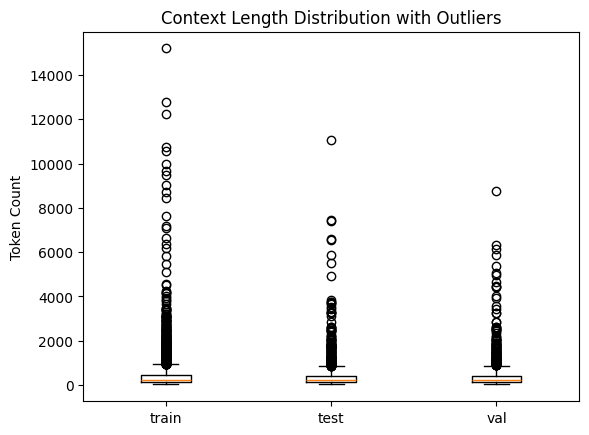

In [ ]:
import matplotlib.pyplot as plt

# prepare data
data = [
    cloud_processed_train['context_len'],
    cloud_processed_test['context_len'],
    cloud_processed_val['context_len']
]
labels = ['train', 'test', 'val']

# create a boxplot (outliers shown as points beyond the whiskers)
plt.figure()
plt.boxplot(data, labels=labels, showfliers=True)
plt.title('Context Length Distribution with Outliers')
plt.ylabel('Token Count')
plt.show()


In [ ]:
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper


In [ ]:
# compute the 1.5·IQR upper-bound for each split
thresholds = {}
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    _, _, upper = find_outliers(df, "context_len")
    thresholds[name] = upper

print(thresholds)

{'train': np.float64(931.5), 'test': np.float64(868.0), 'val': np.float64(883.0)}


In [ ]:
outlier_counts = {}
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    thresh = thresholds[name]
    # mask where context_len exceeds the 1.5·IQR upper‐fence
    mask = df['context_len'] > thresh
    outlier_counts[name] = mask.sum()

# print per‐split and overall
for name, cnt in outlier_counts.items():
    print(f"{name.title()} split outliers: {cnt} rows ({cnt/len(locals()[f'cloud_processed_{name}'])*100:.2f}%)")

total = sum(outlier_counts.values())
print(f"\nTotal outliers across all splits: {total}")


Train split outliers: 442 rows (9.09%)
Test split outliers: 169 rows (10.39%)
Val split outliers: 146 rows (9.40%)

Total outliers across all splits: 757


#### Context Length analysis

In [ ]:
sample = cloud_processed_train.sort_values('context_len', ascending=False).head(20)


In [ ]:
sample.head()

,context,gt,img,context_len
2280,title: Azure/Kubernetes (AKS) - Nginx ingress ...,This problem was solved by changing the extern...,['https://i.sstatic.net/V1RaV.png'],15193
4424,title: Google App Engine Python 3.7 build erro...,\nIt looks like your requirements.txt file is ...,['https://i.sstatic.net/L5N6u.png'],12774
3840,title: problems running python Flask Restplus ...,\nThanks to the error message that you have pr...,['https://i.sstatic.net/WZqgl.png'],12217
2084,title: Heroku fails to install pywin32 library...,From its README:\n\n\n This is the readme for...,['https://i.sstatic.net/ccSit.png'],10760
1951,title: Azure DevOps publish Nuget to hosted fe...,\nI have found the trouble with this at moment...,"['https://i.sstatic.net/5aUOy.png', 'https://i...",10579


In [ ]:
# sample -> longest sequence
row = sample.iloc[3]

print("Row Structure:")
print(f"Context Length: {row['context_len']}")
print(f"Context Preview: {row['context'][:3000]}...")  # Preview only first 100 characters
print()
print(f"GT: {row['gt']}")
print(f"Image: {row['img']}")


Row Structure:
Context Length: 10760
Context Preview: title: Heroku fails to install pywin32 library
body: I'm trying to push my Python application to Heroku but it looks like pywin32 isn't being installed:

Counting objects: 519, done.
Delta compression using up to 4 threads.
Compressing objects: 100% (483/483), done.
Writing objects: 100% (519/519), 7.55 MiB | 136.00 KiB/s, done.
Total 519 (delta 247), reused 0 (delta 0)
remote: Compressing source files... done.
remote: Building source:
remote:
remote: -----> Python app detected
remote: -----> Installing python-3.6.4
remote: -----> Installing pip
remote: -----> Installing requirements with pip
remote:        Collecting aioredis==1.0.0 (from -r /tmp/build_9cc549609c727e83c7b487b43fec0a2e/requirements.txt (line 1))
remote:          Downloading https://files.pythonhosted.org/packages/e6/15/79bc11213e1b918f152914e1de96e5610961da3709e3ca8cc650e00b8f4e/aioredis-1.0.0-py3-none-any.whl (59kB)
remote:        Collecting amqp==2.1.4 (from -r /t

In [ ]:
# sample for smallest squence

In [ ]:
sample = cloud_processed_train.sort_values('context_len', ascending=True).head(20)

In [ ]:
# sample -> longest sequence
row = sample.iloc[5]

print("Row Structure:")
print(f"Context Length: {row['context_len']}")
print(f"Context Body: {row['context']}...")  # Preview only first 100 characters
print()
print(f"GT: {row['gt']}")
print(f"Image: {row['img']}")


Row Structure:
Context Length: 35
Context Body: title: What is Difference between broker-list and bootstrap servers?
body: What is difference between Kafka

broker-list and bootstrap servers...

GT: I also hate reading "wall of text like" Kafka documentation :P
As far as I understand:  


broker-list


a full list of servers, if any missing producer may not work  
related to producer commands  

bootstrap-servers  


one is enough to discover all others  
related to consumer commands  
Zookeeper involved



Sorry for being such... brief. Next time I will focus more on details to be more clear.
To explain my point of view I will use Kafka 1.0.1 console scripts.

kafka-console-consumer.sh

The console consumer is a tool that reads data from Kafka and outputs it to standard output.
Option                                   Description
------                                   -----------
--blacklist <String: blacklist>          Blacklist of topics to exclude from
                           

### *Imgs Analysis*

In [24]:
# img count
def count_imgs(x):
    # parse stringified lists, else use as-is
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return 0
    # return length of list (or 0 if not a list)
    return len(x) if isinstance(x, (list, tuple)) else 0

for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    df['img_count'] = df['img'].apply(count_imgs)

In [25]:
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    stats = df['img_count'].agg(['min', 'max', 'mean', 'count'])
    stats.index = ['min_imgs', 'max_imgs', 'avg_imgs', 'total_rows']
    print(f"--- {name.upper()} SPLIT img_count stats ---")
    print(stats.to_string())
    print()


--- TRAIN SPLIT img_count stats ---
min_imgs         1.000000
max_imgs        21.000000
avg_imgs         2.073088
total_rows    4693.000000

--- TEST SPLIT img_count stats ---
min_imgs         1.00000
max_imgs        17.00000
avg_imgs         2.04273
total_rows    1568.00000

--- VAL SPLIT img_count stats ---
min_imgs         1.000000
max_imgs        20.000000
avg_imgs         2.101078
total_rows    1484.000000



In [ ]:
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    total = len(df)
    cnt = (df['img_count'] > 3 ).sum()
    print(f"{name.title()} split: {total} rows, {cnt} rows >2 images")
    print(f"Percentage: ({cnt/total*100:.2f}%)")
    print("----------------------------")

Train split: 4864 rows, 664 rows >2 images
Percentage: (13.65%)
----------------------------
Test split: 1627 rows, 227 rows >2 images
Percentage: (13.95%)
----------------------------
Val split: 1553 rows, 230 rows >2 images
Percentage: (14.81%)
----------------------------


In [ ]:
import ast
import pandas as pd

# Helper function to count images
def count_imgs(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return 0
    return len(x) if isinstance(x, (list, tuple)) else 0

# Helper function to analyze context length by image count group
def analyze_by_image_group(df, split_name):
    # Count images
    df = df.copy()
    df['img_count'] = df['img'].apply(count_imgs)

    # Define groups
    def group_fn(x):
        if 1 <= x <= 3:
            return "1-3"
        elif 4 <= x <= 7:
            return "4-7"
        elif x >= 8:
            return "8+"
        else:
            return "0"

    df['img_group'] = df['img_count'].apply(group_fn)

    # Filter out entries with 0 images if not relevant
    df = df[df['img_group'] != '0']

    # Group and compute stats
    result = df.groupby('img_group').agg(
        avg_context_len=('context_len', 'mean'),
        count=('context_len', 'count'),
        more_than_3000=('context_len', lambda x: (x > 1000).sum())
    )

    print(f"--- IMAGE CONTEXT ANALYSIS ({split_name.upper()}) ---")
    print(result)
    print()

# Run for each split
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    analyze_by_image_group(df, name)


--- IMAGE CONTEXT ANALYSIS (TRAIN) ---
           avg_context_len  count  more_than_3000
img_group                                        
1-3             416.415000   4200             320
4-7             457.670775    568              57
8+              602.125000     96               8

--- IMAGE CONTEXT ANALYSIS (TEST) ---
           avg_context_len  count  more_than_3000
img_group                                        
1-3             415.248571   1400             111
4-7             434.675258    194              21
8+              619.818182     33               5

--- IMAGE CONTEXT ANALYSIS (VAL) ---
           avg_context_len  count  more_than_3000
img_group                                        
1-3             396.724868   1323              97
4-7             494.782383    193              23
8+              345.621622     37               2



### *Corupted imgs*

In [ ]:
import ast

def bad_extension(df, image_column="img"):
    invalid = []
    for idx, cell in enumerate(df[image_column]):
        # parse stringified list if needed
        if isinstance(cell, str):
            try:
                urls = ast.literal_eval(cell)
            except Exception:
                urls = []
        elif isinstance(cell, (list, tuple)):
            urls = cell
        else:
            urls = []

        # if none of the URLs are .png/.jpg, mark as invalid
        if not any(
            str(u).lower().split("?", 1)[0].endswith((".png", ".jpg"))
            for u in urls
        ):
            invalid.append(idx)

    return invalid

In [ ]:
extension_train = bad_extension(cloud_processed_train)
extension_test = bad_extension(cloud_processed_test)
extension_val = bad_extension(cloud_processed_val)

print("Train rows without any .png/.jpg images:", len(extension_train))
print("Test rows without any .png/.jpg images:", len(extension_test))
print("Val rows without any .png/.jpg images:", len(extension_val))

Train rows without any .png/.jpg images: 34
Test rows without any .png/.jpg images: 7
Val rows without any .png/.jpg images: 16


In [ ]:
import re
import ast
from urllib.parse import urlparse

# Precompiled regex patterns
double_re = re.compile(r'https?://.*https?://', re.IGNORECASE)
scheme_re = re.compile(r'^https?://', re.IGNORECASE)
ext_re = re.compile(r'\.(?:png|jpe?g|gif|svg)(?:\?.*)?$', re.IGNORECASE)
suspicious_ext_re = re.compile(r'\.(gif|svg).*?\.(png|jpe?g|gif|svg)', re.IGNORECASE)

def parse_cell(cell):
    """Turn stringified lists into real lists, else return as-is or empty list."""
    if isinstance(cell, str):
        try:
            return ast.literal_eval(cell)
        except Exception:
            return []
    return cell or []

def count_rows_with_bad_urls(df, image_column="images"):
    bad_rows = set()
    reasons = []

    for row_idx, cell in enumerate(df[image_column]):
        urls = parse_cell(cell)
        for img_idx, u in enumerate(urls):
            u = str(u).strip()

            # Check malformed or redundant schemes
            if double_re.search(u):
                reasons.append((row_idx, img_idx, u, 'double_scheme'))
            elif not scheme_re.match(u):
                reasons.append((row_idx, img_idx, u, 'missing_scheme'))
            elif suspicious_ext_re.search(u):
                reasons.append((row_idx, img_idx, u, 'suspicious_double_extension'))
            elif not ext_re.search(u):
                reasons.append((row_idx, img_idx, u, 'bad_extension'))
            else:
                p = urlparse(u)
                if not (p.netloc and p.path):
                    reasons.append((row_idx, img_idx, u, 'malformed_url'))
                else:
                    continue  # this URL is fine, check next

            bad_rows.add(row_idx)
            break  # stop at first bad URL in this row

    return bad_rows, reasons


In [ ]:
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    total = len(df)
    bad_rows, reasons = count_rows_with_bad_urls(df, image_column="img")
    num_bad   = len(bad_rows)
    num_clean = total - num_bad

    print(f"\n=== {name.title()} split ===")
    print(f"Total rows: {total}")
    print(f"Bad-URL rows: {num_bad}")
    print(f"Clean rows: {num_clean}\n")

    for row_idx, img_idx, url, reason in reasons:
        print(f" Row {row_idx}, Img#{img_idx}: {url!r} → {reason}")



=== Train split ===
Total rows: 4864
Bad-URL rows: 12
Clean rows: 4852

 Row 837, Img#0: 'https://qetza.gallerycdn.vsassets.io/extensions/qetza/replacetokens/3.0.0/1533623408426/Microsoft.VisualStudio.Services.Screenshots.1' → bad_extension
 Row 1062, Img#0: 'https://web.archive.org/web/20140313064839/http://www.freeimagehosting.net/uploads/fc176c0957.png' → double_scheme
 Row 2315, Img#11: 'https://miro.medium.com/max/1050/0*QU10HoQwT1kfcsfR' → bad_extension
 Row 2716, Img#0: 'https://s3.amazonaws.com/cerenity/SOResources/favicon.ico' → bad_extension
 Row 3114, Img#1: '//i.sstatic.net/6mhd8.png' → missing_scheme
 Row 3180, Img#2: 'https://img.shields.io/pypi/pyversions/pysecret' → bad_extension
 Row 3752, Img#0: 'https://drive.google.com/uc?id=1vXzQ9vpdtnfDYAW-tg5--NsrZbksnpku' → bad_extension
 Row 4066, Img#0: 'https://upload.wikimedia.org/wikipedia/commons/thumb/f/f7/Binary_tree.svg/220px-Binary_tree.svg.png' → suspicious_double_extension
 Row 4164, Img#2: 'https://www.gravatar.com

### Img size

In [ ]:
import ast
import requests
from PIL import Image
from io import BytesIO

def fetch_size(url, timeout=5):

    try:
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content))
        return img.width, img.height
    except Exception:
        return None, None

def analyze_images(df, image_column="img"):
    resolutions   = []
    aspect_ratios = []

    for cell in df[image_column]:
        # step 1: parse string-lists into actual lists
        if isinstance(cell, str):
            try:
                urls = ast.literal_eval(cell)
            except Exception:
                urls = []
        elif isinstance(cell, (list, tuple)):
            urls = cell
        else:
            urls = []

        row_res = []
        row_ar  = []
        # step 2: fetch sizes
        for u in urls:
            w, h = fetch_size(u)
            if w and h:
                row_res.append((w, h))
                row_ar.append(w / h)
        resolutions.append(row_res)
        aspect_ratios.append(row_ar)

    # attach back to df
    df['resolutions']   = resolutions
    df['aspect_ratios'] = aspect_ratios
    return df

# now run it for each split and summarize
for name, df in [
    ("train", cloud_processed_train),
    ("test",  cloud_processed_test),
    ("val",   cloud_processed_val)
]:
    print(f"Processing {name} split…")
    df = analyze_images(df)  # mutates df in-place too
    # flatten all values
    all_res = [wh for sub in df['resolutions']   for wh in sub]
    all_ar  = [ar for sub in df['aspect_ratios'] for ar in sub]

    if all_res:
        widths, heights = zip(*all_res)
        print(f"  Resolution → min={min(widths)}×{min(heights)}, "
              f"max={max(widths)}×{max(heights)}, "
              f"avg≈{int(sum(widths)/len(widths))}×{int(sum(heights)/len(heights))}")

    if all_ar:
        print(f"  Aspect Ratio → min={min(all_ar):.2f}, "
              f"max={max(all_ar):.2f}, "
              f"avg={sum(all_ar)/len(all_ar):.2f}")
    print()

Processing train split…


KeyboardInterrupt: 

## Device

### *Min*, *Max* and *Avg*

<b><h3> Context Text </h3> </b>

In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [36]:
# tokenize setup
def text_length(text, add_special_tokens=True):
    if pd.isnull(text) or not isinstance(text, str) or not text.strip():
        return 0
    temp_inputs = tokenizer(text, return_tensors="pt", add_special_tokens=add_special_tokens)
    return temp_inputs.input_ids.shape[1]


In [37]:
# apply tokenize
for df in (device_processed_train, device_processed_test, device_processed_val):
    df['context_len'] = df['context'].apply(lambda txt: text_length(txt))

In [38]:
device_processed_train.head(1)

,context,gt,img,context_len
0,title: WireShark Remote Capture failed:NFLOG l...,The error message is explaining what is the ca...,"['https://i.sstatic.net/E1u6R.png', 'https://i...",357


In [39]:
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    stats = df['context_len'].agg(
        total='count',
        minimum='min',
        maximum='max',
        average='mean',
    )
    print(f"--- Device {name.upper()} SPLIT ---")
    print(stats.to_string())
    print()


--- Device TRAIN SPLIT ---
total       2942.000000
minimum       30.000000
maximum    13869.000000
average      447.274303

--- Device TEST SPLIT ---
total        947.000000
minimum       27.000000
maximum    11785.000000
average      444.796199

--- Device VAL SPLIT ---
total        991.000000
minimum       32.000000
maximum    10381.000000
average      438.594349



In [ ]:
print(device_processed_train['context'].loc[1386])

title: Windows Folder Permission
body: May i check for the below folder rights, is the user able to read files inside of the folder?


In [ ]:
device_processed_train['context_len'].sort_values(ascending=True).head(10)

,context_len
1460,30
2089,30
1386,33
2885,33
280,34
2346,36
74,37
864,38
220,38
1015,38


#### Outliers

<ipython-input-72-117782b90175>:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=True)


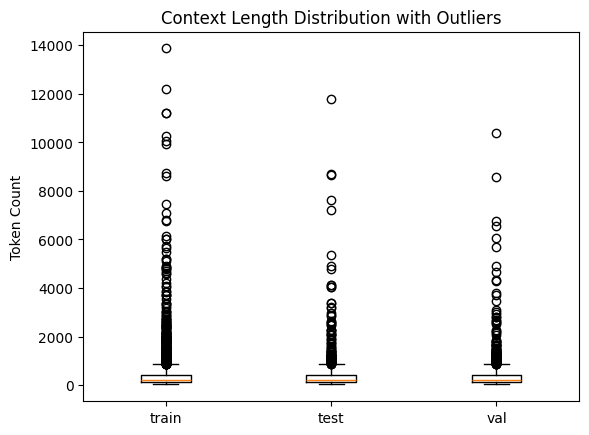

In [ ]:
import matplotlib.pyplot as plt

# prepare data
data = [
    device_processed_train['context_len'],
    device_processed_test['context_len'],
    device_processed_val['context_len']
]
labels = ['train', 'test', 'val']

# create a boxplot (outliers shown as points beyond the whiskers)
plt.figure()
plt.boxplot(data, labels=labels, showfliers=True)
plt.title('Context Length Distribution with Outliers')
plt.ylabel('Token Count')
plt.show()


In [ ]:
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    mask = (df[col] < lower) | (df[col] > upper)
    return mask, lower, upper


In [ ]:
# compute the 1.5·IQR upper-bound for each split
thresholds = {}
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    _, _, upper = find_outliers(df, "context_len")
    thresholds[name] = upper

print(thresholds)

{'train': np.float64(864.25), 'test': np.float64(877.0), 'val': np.float64(866.75)}


In [ ]:
outlier_counts = {}
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    thresh = thresholds[name]
    # mask where context_len exceeds the 1.5·IQR upper‐fence
    mask = df['context_len'] > thresh
    outlier_counts[name] = mask.sum()

# print per‐split and overall
for name, cnt in outlier_counts.items():
    print(f"{name.title()} split outliers: {cnt} rows ({cnt/len(locals()[f'cloud_processed_{name}'])*100:.2f}%)")

total = sum(outlier_counts.values())
print(f"\nTotal outliers across all splits: {total}")


Train split outliers: 305 rows (6.27%)
Test split outliers: 100 rows (6.15%)
Val split outliers: 113 rows (7.28%)

Total outliers across all splits: 518


#### context length analysis

In [ ]:
sample = device_processed_train.sort_values('context_len', ascending=False).head(20)

In [ ]:
# sample -> longest sequence
row = sample.iloc[8]

print("Row Structure:")
print(f"Context Length: {row['context_len']}")
print(f"Context Body: {row['context'][:4000]}...")  # Preview only first 100 characters
print()
print(f"GT: {row['gt']}")
print(f"Image: {row['img']}")


Row Structure:
Context Length: 8616
Context Body: title: Why cant i reach the other network while i have added the routes and firewall rules to allow traffic? (Pfsense/USG200)
body: I have 2 networks, the current one and the new one. The current one is not configured by me and one big mess and contains heavily out dated hardware (especially servers). I want to be able to access the complete current network from the new one so i can migrate server for server and device for device. 

Some network details:


Current network: 


IP: 192.168.1.1
IP range: 192.168.104.0/24
Router/firewall: Zyxel USG200
Contain all devices
Gives DHCP address to Pfsense (192.168.104.4/24)

New network:


IP: 10.128.10.1
IP range: 10.128.10.0/24.
Router/firewall: Pfsense
Currently it contains only 1 device, my desktop but this network will replace the current one in future
All devices will be "moved" from the old to the new network by time (one for one)
Connected with old network by port with alias "WAN 2"



I

### *Imgs Analysis*

In [40]:
# img count
def count_imgs(x):
    # parse stringified lists, else use as-is
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return 0
    # return length of list (or 0 if not a list)
    return len(x) if isinstance(x, (list, tuple)) else 0

for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    df['img_count'] = df['img'].apply(count_imgs)

In [41]:
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    stats = df['img_count'].agg(['min', 'max', 'mean', 'count'])
    stats.index = ['min_imgs', 'max_imgs', 'avg_imgs', 'total_rows']
    print(f"--- {name.upper()} SPLIT img_count stats ---")
    print(stats.to_string())
    print()


--- TRAIN SPLIT img_count stats ---
min_imgs         1.000000
max_imgs        39.000000
avg_imgs         1.690007
total_rows    2942.000000

--- TEST SPLIT img_count stats ---
min_imgs        1.000000
max_imgs       11.000000
avg_imgs        1.642027
total_rows    947.000000

--- VAL SPLIT img_count stats ---
min_imgs        1.000000
max_imgs       12.000000
avg_imgs        1.649849
total_rows    991.000000



In [ ]:
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    total = len(df)
    cnt = (df['img_count'] > 3 ).sum()
    print(f"{name.title()} split: {total} rows, {cnt} rows >2 images")
    print(f"Percentage: ({cnt/total*100:.2f}%)")
    print("----------------------------")

Train split: 3127 rows, 238 rows >2 images
Percentage: (7.61%)
----------------------------
Test split: 1021 rows, 70 rows >2 images
Percentage: (6.86%)
----------------------------
Val split: 1047 rows, 76 rows >2 images
Percentage: (7.26%)
----------------------------


In [ ]:
import ast
import pandas as pd

# Helper function to count images
def count_imgs(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return 0
    return len(x) if isinstance(x, (list, tuple)) else 0

# Helper function to analyze context length by image count group
def analyze_by_image_group(df, split_name):
    # Count images
    df = df.copy()
    df['img_count'] = df['img'].apply(count_imgs)

    # Define groups
    def group_fn(x):
        if 1 <= x <= 3:
            return "1-3"
        elif 4 <= x <= 7:
            return "4-7"
        elif x >= 8:
            return "8+"
        else:
            return "0"

    df['img_group'] = df['img_count'].apply(group_fn)

    # Filter out entries with 0 images if not relevant
    df = df[df['img_group'] != '0']

    # Group and compute stats
    result = df.groupby('img_group').agg(
        avg_context_len=('context_len', 'mean'),
        count=('context_len', 'count'),
        more_than_3000=('context_len', lambda x: (x > 1000).sum())
    )

    print(f"--- IMAGE CONTEXT ANALYSIS ({split_name.upper()}) ---")
    print(result)
    print()

# Run for each split
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    analyze_by_image_group(df, name)


--- IMAGE CONTEXT ANALYSIS (TRAIN) ---
           avg_context_len  count  more_than_3000
img_group                                        
1-3             430.038768   2889             232
4-7             625.605911    203              23
8+              405.200000     35               3

--- IMAGE CONTEXT ANALYSIS (TEST) ---
           avg_context_len  count  more_than_3000
img_group                                        
1-3             441.698212    951              76
4-7             407.229508     61               4
8+              415.333333      9               1

--- IMAGE CONTEXT ANALYSIS (VAL) ---
           avg_context_len  count  more_than_3000
img_group                                        
1-3             427.694130    971              84
4-7             507.777778     63               6
8+              422.076923     13               0



### *Corupted imgs*

In [ ]:
"""import ast

def bad_extension(df, image_column="img"):
    invalid = []
    for idx, cell in enumerate(df[image_column]):
        # parse stringified list if needed
        if isinstance(cell, str):
            try:
                urls = ast.literal_eval(cell)
            except Exception:
                urls = []
        elif isinstance(cell, (list, tuple)):
            urls = cell
        else:
            urls = []

        # if none of the URLs are .png/.jpg, mark as invalid
        if not any(
            str(u).lower().split("?", 1)[0].endswith((".png", ".jpg"))
            for u in urls
        ):
            invalid.append(idx)

    return invalid"""

'import ast\n\ndef bad_extension(df, image_column="img"):\n    invalid = []\n    for idx, cell in enumerate(df[image_column]):\n        # parse stringified list if needed\n        if isinstance(cell, str):\n            try:\n                urls = ast.literal_eval(cell)\n            except Exception:\n                urls = []\n        elif isinstance(cell, (list, tuple)):\n            urls = cell\n        else:\n            urls = []\n\n        # if none of the URLs are .png/.jpg, mark as invalid\n        if not any(\n            str(u).lower().split("?", 1)[0].endswith((".png", ".jpg"))\n            for u in urls\n        ):\n            invalid.append(idx)\n\n    return invalid'

In [ ]:
cloud_multimodal_train['images'][:3]

,images
0,['https://i.sstatic.net/D7pQd.png']
1,['https://i.sstatic.net/Ku2DV.png']
2,"['https://i.sstatic.net/vUGt6.png', 'https://i..."


In [ ]:
#update
import ast

def bad_extension(df, image_column="img"):
    invalid = []
    for idx, cell in enumerate(df[image_column]):
        # Parse if string (e.g., "['url1', 'url2']")
        if isinstance(cell, str):
            try:
                urls = ast.literal_eval(cell)
                if not isinstance(urls, (list, tuple)):  # Protect against plain strings
                    urls = [cell]
            except Exception:
                urls = [cell]  # Fallback to treating as single URL string
        elif isinstance(cell, (list, tuple)):
            urls = cell
        else:
            urls = []

        # Normalize and check for all valid extensions
        valid = all(
            str(u).strip().lower().split("?", 1)[0].endswith((".png", ".jpg", ".jpeg"))
            for u in urls
        )
        if not valid:
            invalid.append(idx)

    return invalid

In [ ]:
extension_train = bad_extension(device_processed_train)
extension_test = bad_extension(device_processed_test)
extension_val = bad_extension(device_processed_val)

print("Train rows without any .png/.jpg images:", len(extension_train))
print("Test rows without any .png/.jpg images:", len(extension_test))
print("Val rows without any .png/.jpg images:", len(extension_val))

Train rows without any .png/.jpg images: 58
Test rows without any .png/.jpg images: 36
Val rows without any .png/.jpg images: 36


In [ ]:
"""   # find how many corrupted paths in imgs
import re
import ast
from urllib.parse import urlparse

# Precompiled regex patterns
double_re = re.compile(r'https?://.*https?://', re.IGNORECASE)
scheme_re = re.compile(r'^https?://', re.IGNORECASE)
ext_re = re.compile(r'\.(?:png|jpe?g|gif|svg)(?:\?.*)?$', re.IGNORECASE)

def parse_cell(cell):
    if isinstance(cell, str):
        try:
            return ast.literal_eval(cell)
        except Exception:
            return []
    return cell or []

def count_rows_with_bad_urls(df, image_column="images"):
    bad_rows = set()
    reasons = []

    for row_idx, cell in enumerate(df[image_column]):
        urls = parse_cell(cell)
        for img_idx, u in enumerate(urls):
            u = str(u).strip()
            if double_re.search(u):
                reasons.append((row_idx, img_idx, u, 'double_scheme'))
            elif not scheme_re.match(u):
                reasons.append((row_idx, img_idx, u, 'missing_scheme'))
            elif not ext_re.search(u):
                reasons.append((row_idx, img_idx, u, 'bad_extension'))
            else:
                p = urlparse(u)
                if not (p.netloc and p.path):
                    reasons.append((row_idx, img_idx, u, 'malformed_url'))
                else:
                    continue  # this URL is fine, check next
            bad_rows.add(row_idx)
            break  # stop at first bad URL in this row

    return bad_rows, reasons"""

'   # find how many corrupted paths in imgs\nimport re\nimport ast\nfrom urllib.parse import urlparse\n\n# Precompiled regex patterns\ndouble_re = re.compile(r\'https?://.*https?://\', re.IGNORECASE)\nscheme_re = re.compile(r\'^https?://\', re.IGNORECASE)\next_re = re.compile(r\'\\.(?:png|jpe?g|gif|svg)(?:\\?.*)?$\', re.IGNORECASE)\n\ndef parse_cell(cell):\n    if isinstance(cell, str):\n        try:\n            return ast.literal_eval(cell)\n        except Exception:\n            return []\n    return cell or []\n\ndef count_rows_with_bad_urls(df, image_column="images"):\n    bad_rows = set()\n    reasons = []\n\n    for row_idx, cell in enumerate(df[image_column]):\n        urls = parse_cell(cell)\n        for img_idx, u in enumerate(urls):\n            u = str(u).strip()\n            if double_re.search(u):\n                reasons.append((row_idx, img_idx, u, \'double_scheme\'))\n            elif not scheme_re.match(u):\n                reasons.append((row_idx, img_idx, u, \'missi

In [ ]:
import re
import ast
from urllib.parse import urlparse

# Precompiled regex patterns
double_re = re.compile(r'https?://.*https?://', re.IGNORECASE)
scheme_re = re.compile(r'^https?://', re.IGNORECASE)
ext_re = re.compile(r'\.(?:png|jpe?g|gif|svg)(?:\?.*)?$', re.IGNORECASE)
suspicious_ext_re = re.compile(r'\.(gif|svg).*?\.(png|jpe?g|gif|svg)', re.IGNORECASE)

def parse_cell(cell):
    """Turn stringified lists into real lists, else return as-is or empty list."""
    if isinstance(cell, str):
        try:
            return ast.literal_eval(cell)
        except Exception:
            return []
    return cell or []

def count_rows_with_bad_urls(df, image_column="images"):
    bad_rows = set()
    reasons = []

    for row_idx, cell in enumerate(df[image_column]):
        urls = parse_cell(cell)
        for img_idx, u in enumerate(urls):
            u = str(u).strip()

            # Check malformed or redundant schemes
            if double_re.search(u):
                reasons.append((row_idx, img_idx, u, 'double_scheme'))
            elif not scheme_re.match(u):
                reasons.append((row_idx, img_idx, u, 'missing_scheme'))
            elif suspicious_ext_re.search(u):
                reasons.append((row_idx, img_idx, u, 'suspicious_double_extension'))
            elif not ext_re.search(u):
                reasons.append((row_idx, img_idx, u, 'bad_extension'))
            else:
                p = urlparse(u)
                if not (p.netloc and p.path):
                    reasons.append((row_idx, img_idx, u, 'malformed_url'))
                else:
                    continue  # this URL is fine, check next

            bad_rows.add(row_idx)
            break  # stop at first bad URL in this row

    return bad_rows, reasons


In [ ]:
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    total = len(df)
    bad_rows, reasons = count_rows_with_bad_urls(df, image_column="img")
    num_bad   = len(bad_rows)
    num_clean = total - num_bad

    print(f"\n=== {name.title()} split ===")
    print(f"Total rows: {total}")
    print(f"Bad-URL rows: {num_bad}")
    print(f"Clean rows: {num_clean}\n")

    for row_idx, img_idx, url, reason in reasons:
        print(f" Row {row_idx}, Img#{img_idx}: {url!r} → {reason}")



=== Train split ===
Total rows: 3127
Bad-URL rows: 13
Clean rows: 3114

 Row 142, Img#0: 'https://github.com/spring-projects/spring-boot/assets/4410920/c084c537-d5e4-4d29-aa6a-9325db1fb573' → bad_extension
 Row 370, Img#0: 'https://www.plantuml.com/plantuml/svg/oojFoKnCLwZcKb38Ioqfpo_ALl1nz8it08fmAYWafgGKfHONAzWgA1bQ6kaPcbde6UWPw1kPA74fW451Md1gNd5gl7jYIMfvOgL2D5OTXagnrY3ZWeCzK5IabcGOMYcu-8Vx8HJ4E-TafkQLu3B9s0oaL46XbWlDnKQ6XZZT39I3kDgQ2v-xCNNXSxc1bGAAIaDBAoCZcEDg0G00' → bad_extension
 Row 391, Img#0: 'https://upload.wikimedia.org/wikipedia/commons/thumb/2/2b/Digital_Signature_diagram.svg/800px-Digital_Signature_diagram.svg.png' → suspicious_double_extension
 Row 722, Img#1: 'https://kroki.io/plantuml/svg/eNqd0cEKAiEQgOG7TzH4AKYSUUSw7xEdhJGQ1hHUZQ-x7x7KIhG7IHkcvhn4cUjZxDz5kdGMzjzhzQDI5jnEFzgiG-ukPIMYbUpwA64uWqjTWWghD_rI2Sqqp4BWwn1TK8kf11-s9rDawHoP64JX7R3iaL2hsr58BYUpdwW1S3Wht6jhnqKG_yla2GAJy699AIOhd2k=' → bad_extension
 Row 1854, Img#2: 'https://github.com/user-attachments/assets/114a66

### Img Size

In [ ]:
import ast
import requests
from PIL import Image
from io import BytesIO

def fetch_size(url, timeout=5):

    try:
        resp = requests.get(url, timeout=timeout)
        resp.raise_for_status()
        img = Image.open(BytesIO(resp.content))
        return img.width, img.height
    except Exception:
        return None, None

def analyze_images(df, image_column="img"):
    resolutions   = []
    aspect_ratios = []

    for cell in df[image_column]:
        # step 1: parse string-lists into actual lists
        if isinstance(cell, str):
            try:
                urls = ast.literal_eval(cell)
            except Exception:
                urls = []
        elif isinstance(cell, (list, tuple)):
            urls = cell
        else:
            urls = []

        row_res = []
        row_ar  = []
        # step 2: fetch sizes
        for u in urls:
            w, h = fetch_size(u)
            if w and h:
                row_res.append((w, h))
                row_ar.append(w / h)
        resolutions.append(row_res)
        aspect_ratios.append(row_ar)

    # attach back to df
    df['resolutions']   = resolutions
    df['aspect_ratios'] = aspect_ratios
    return df

# now run it for each split and summarize
for name, df in [
    ("train", device_processed_train),
    ("test",  device_processed_test),
    ("val",   device_processed_val)
]:
    print(f"Processing {name} split…")
    df = analyze_images(df)  # mutates df in-place too
    # flatten all values
    all_res = [wh for sub in df['resolutions']   for wh in sub]
    all_ar  = [ar for sub in df['aspect_ratios'] for ar in sub]

    if all_res:
        widths, heights = zip(*all_res)
        print(f"  Resolution → min={min(widths)}×{min(heights)}, "
              f"max={max(widths)}×{max(heights)}, "
              f"avg≈{int(sum(widths)/len(widths))}×{int(sum(heights)/len(heights))}")

    if all_ar:
        print(f"  Aspect Ratio → min={min(all_ar):.2f}, "
              f"max={max(all_ar):.2f}, "
              f"avg={sum(all_ar)/len(all_ar):.2f}")
    print()

Processing train split…


KeyboardInterrupt: 

# Cleaning

## Coruppted Images

In [ ]:
import pandas as pd
import ast
import re
from urllib.parse import urlparse

# Precompiled regex patterns
double_re = re.compile(r'https?://.*https?://', re.IGNORECASE)
scheme_re = re.compile(r'^https?://', re.IGNORECASE)
suspicious_ext_re = re.compile(r'\.(gif|svg)[^/]*?\.(png|jpe?g)', re.IGNORECASE)  # matches .gif.png, .svg.jpeg etc.

# Only these extensions are allowed
ALLOWED_EXTENSIONS = ('.png', '.jpg')

def is_valid_url(u):
    """Check if a URL passes all conditions."""
    u = str(u).strip()
    base_url = u.split("?", 1)[0].lower()

    # Extension must be .png or .jpg only
    if not base_url.endswith(ALLOWED_EXTENSIONS):
        return False, 'bad_extension'

    # Catch suspicious compound extensions like .gif.png
    if suspicious_ext_re.search(base_url):
        return False, 'suspicious_double_extension'

    # Must start with http:// or https://
    if not scheme_re.match(u):
        return False, 'missing_scheme'

    # Must not contain double scheme
    if double_re.search(u):
        return False, 'double_scheme'

    # URL must parse cleanly
    parsed = urlparse(u)
    if not (parsed.netloc and parsed.path):
        return False, 'malformed_url'

    return True, None

def parse_cell(cell):
    """Safely convert a cell into a list of URLs."""
    if isinstance(cell, str):
        try:
            parsed = ast.literal_eval(cell)
            if isinstance(parsed, (list, tuple)):
                return list(parsed)
            return [cell]
        except Exception:
            return [cell]
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return []

def clean_image_urls(df: pd.DataFrame, image_column: str = "img"):
    """
    Cleans a DataFrame by removing rows containing any invalid image URL.
    Only .png and .jpg images are allowed. Returns a cleaned DataFrame and list of issues.
    """
    bad_rows = set()
    reasons = []

    for idx, cell in enumerate(df[image_column]):
        urls = parse_cell(cell)

        for img_idx, url in enumerate(urls):
            valid, reason = is_valid_url(url)
            if not valid:
                reasons.append((idx, img_idx, url, reason))
                bad_rows.add(idx)
                break  # Stop checking further URLs in this row

    # Drop bad rows
    df_cleaned = df.drop(index=list(bad_rows)).reset_index(drop=True)
    return df_cleaned, reasons


In [ ]:
import pandas as pd
import ast
import re
from urllib.parse import urlparse

# Precompiled regex patterns
double_re = re.compile(r'https?://.*https?://', re.IGNORECASE)
scheme_re = re.compile(r'^https?://', re.IGNORECASE)
suspicious_ext_re = re.compile(r'\.(gif|svg)[^/]*?\.(png|jpe?g)', re.IGNORECASE)  # matches .gif.png, .svg.jpeg etc.

# Only these extensions are allowed
ALLOWED_EXTENSIONS = ('.png', '.jpg')
ALLOWED_DOMAIN = 'i.sstatic.net'

def is_valid_url(u):
    """Check if a URL passes all conditions."""
    u = str(u).strip()
    base_url = u.split("?", 1)[0].lower()

    # Extension must be .png or .jpg only
    if not base_url.endswith(ALLOWED_EXTENSIONS):
        return False, 'bad_extension'

    # Catch suspicious compound extensions like .gif.png
    if suspicious_ext_re.search(base_url):
        return False, 'suspicious_double_extension'

    # Must start with http:// or https://
    if not scheme_re.match(u):
        return False, 'missing_scheme'

    # Must not contain double scheme
    if double_re.search(u):
        return False, 'double_scheme'

    # URL must parse cleanly
    parsed = urlparse(u)
    if not (parsed.netloc and parsed.path):
        return False, 'malformed_url'

    # Must match the allowed domain
    if parsed.netloc.lower() != ALLOWED_DOMAIN:
        return False, 'unapproved_domain'

    return True, None

def parse_cell(cell):
    """Safely convert a cell into a list of URLs."""
    if isinstance(cell, str):
        try:
            parsed = ast.literal_eval(cell)
            if isinstance(parsed, (list, tuple)):
                return list(parsed)
            return [cell]
        except Exception:
            return [cell]
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return []

def clean_image_urls(df: pd.DataFrame, image_column: str = "img"):
    """
    Cleans a DataFrame by removing rows containing any invalid image URL.
    Only .png and .jpg from i.sstatic.net are allowed. Returns cleaned DataFrame and reasons.
    """
    bad_rows = set()
    reasons = []

    for idx, cell in enumerate(df[image_column]):
        urls = parse_cell(cell)

        for img_idx, url in enumerate(urls):
            valid, reason = is_valid_url(url)
            if not valid:
                reasons.append((idx, img_idx, url, reason))
                bad_rows.add(idx)
                break  # Stop checking further URLs in this row

    df_cleaned = df.drop(index=list(bad_rows)).reset_index(drop=True)
    return df_cleaned, reasons


## Cloud

### Llama

In [ ]:
import pandas as pd

# Replace filenames with exact uploaded names if they differ
llama_vl_device_cot_score = pd.read_csv("llama-vl-device-cot-score.csv")
#llama_vl_device_zero_shot_score = pd.read_csv("llama-vl-device-zero-shot-score.csv")
#llama_vl_cloud_cot_score = pd.read_csv("llama-vl-cloud-cot-score.csv")
#llama_vl_cloud_zero_shot_score = pd.read_csv("llama-vl-cloud-zero-shot-score.csv")


In [ ]:
#llama_vl_device_cot_score.shape

(993, 14)

In [ ]:
cloud_list = [1587, 1467, 1147, 1148, 942, 943, 911, 743, 563, 491, 189, 153]
device_list = [114, 153, 189, 223, 491, 563, 743, 787, 911, 942, 943, 622, 464, 622, 686]

In [ ]:
bad_images_rows_no_cloud_test = [
    50, 307, 387, 400,401,425,667, 738,
    783, 863, 887,1185, 1243, 1326, 1388, 1434, 1508, 1538
]

bad_images_rows_no_cloud_val = [
    60,61, 71, 97, 213, 395, 417, 808, 1006,
    1219, 1228, 1225
]

bad_images_rows_no_cloud_train = [
    444,449, 728, 819, 877, 888, 919, 963, 993, 1157,
    1142, 1155, 1515, 1899, 1947, 1984, 2047, 2107, 2109,
    2118, 2306, 2333, 2353, 2398, 2410,
    2449, 2462, 2466, 2508, 2510, 2581,
    2604, 2636, 2677, 2969, 2989, 3149,
    3164, 3336, 3493,3948,4016
]


print("bad images cloud train:",f"{len(bad_images_rows_no_cloud_train)} rows")
print("bad images cloud test:",f"{len(bad_images_rows_no_cloud_test)} rows")
print("bad images cloud val:",f"{len(bad_images_rows_no_cloud_val)} rows")

bad images cloud train: 42 rows
bad images cloud test: 18 rows
bad images cloud val: 12 rows


In [ ]:
bad_images_rows_no_device_train = [
    0, 77, 79, 255, 372, 377, 436, 478, 488, 492,
    487, 504, 529, 528, 534, 533, 538, 560, 690,
    856, 863, 866, 502, 962, 963, 1027,
    1120, 1165, 1166, 1181, 1274, 1275, 1279, 1283,1291,
    1302,1320, 1322, 1884, 2690, 2080, 2091,2096, 2184, 2188,
    2198, 220, 2253, 2295,2298,2316,2349,2364,2366,2369,2391,2427,2495,2821,2842,2859,3029,3034,3055,3058,3059
]

bad_images_rows_no_device_val = [
    32,58,68,72,92,94,95,119,122,158,167,171,172,195,229,232,272,293,291,312,395,448,731,757,784,792
]

bad_images_rows_no_device_test = [
   83,186,300,321,335,387,756,765,895,976
]



print("bad images cloud train:",f"{len(bad_images_rows_no_device_train)} rows")
print("bad images cloud test:",f"{len(bad_images_rows_no_device_test)} rows")
print("bad images cloud val:",f"{len(bad_images_rows_no_device_val)} rows")

bad images cloud train: 66 rows
bad images cloud test: 10 rows
bad images cloud val: 26 rows


In [ ]:
llama_vl_cloud_cot_score.head(2)

,Unnamed: 0,context,gt,img,cot-question,cot-question-length,llama3.2-vl-cot-generated-response,cot-BLEU,cot-RougeL,cot-RougeLsum,cot-BERT-Precision,cot-BERT-Recall,cot-BERT-F1,cot-METEOR
0,0,title: Some recently changed resources are not...,"If that happens for whatever reasons, you need...",['https://i.sstatic.net/QQmRh.png'],\nYou are an expert cloud assistant. Provide a...,126,"The error message ""Some recently changed resou...",0.047184,0.093366,0.147420,0.804087,0.829574,0.816632,0.220353
1,1,title: FAILED TO INITIALIZE RUN FROM PACKAGE.t...,\nI am almost certain that the package path is...,"['https://i.sstatic.net/VJ1po.png', 'https://i...",\nYou are an expert cloud assistant. Provide a...,397,**Step 1: Identify the issue**\n\nThe issue is...,0.078100,0.127907,0.151163,0.824998,0.798818,0.811697,0.172800


In [ ]:
# Drop bad image rows from LLaVA test sets
#llama_vl_cloud_cot_score.drop(cloud_list, inplace=True)
#llama_vl_cloud_zero_shot_score.drop(cloud_list, inplace=True)

llama_vl_device_cot_score.drop(device_list, inplace=True)
#llama_vl_device_zero_shot_score.drop(device_list, inplace=True)

In [ ]:
# Drop rows with bad images from LLaMA test set
#llama_vl_cloud_cot_score.drop(bad_images_rows_no_cloud_test, inplace=True, errors='ignore')
#llama_vl_cloud_cot_score.reset_index(drop=True, inplace=True)

#llama_vl_cloud_zero_shot_score.drop(bad_images_rows_no_cloud_test, inplace=True, errors='ignore')
#llama_vl_cloud_zero_shot_score.reset_index(drop=True, inplace=True)

llama_vl_device_cot_score.drop(bad_images_rows_no_device_test, inplace=True, errors='ignore')
llama_vl_device_cot_score.reset_index(drop=True, inplace=True)

#llama_vl_device_zero_shot_score.drop(bad_images_rows_no_device_test, inplace=True, errors='ignore')
#llama_vl_device_zero_shot_score.reset_index(drop=True, inplace=True)


In [ ]:
llama_vl_cloud_cot_score.shape

(1592, 14)

In [ ]:
llama_vl_device_cot_score.shape

(969, 14)

In [ ]:
# Clean image URLs for each dataset and assign scores with corresponding issue logs
llama_vl_device_cot_score, issues_device_cot = clean_image_urls(llama_vl_device_cot_score, image_column="img")
#llama_vl_device_zero_shot_score, issues_device_zero = clean_image_urls(llama_vl_device_zero_shot_score, image_column="img")
#llama_vl_cloud_cot_score, issues_cloud_cot = clean_image_urls(llama_vl_cloud_cot_score, image_column="img")
#llama_vl_cloud_zero_shot_score, issues_cloud_zero = clean_image_urls(llama_vl_cloud_zero_shot_score, image_column="img")


In [ ]:
print("Device CoT issues:", len(issues_device_cot))
#print("Device Zero-Shot issues:", len(issues_device_zero))
#print("Cloud CoT issues:", len(issues_cloud_cot))
#print("Cloud Zero-Shot issues:", len(issues_cloud_zero))


Device CoT issues: 22


In [ ]:
llama_vl_device_cot_score.shape

(947, 14)

In [ ]:
llama_vl_cloud_cot_score.shape

(1568, 14)

In [ ]:
llama_vl_device_cot_score.shape

(947, 14)

In [ ]:
device_test.shape

(947, 12)

In [ ]:
llama_vl_device_cot_score.to_csv("llama_vl_device_cot_score_cleanx.csv", index=False)

In [ ]:
# Save cleaned LLaMA test CSVs
#llama_vl_cloud_cot_score.to_csv("llama_vl_cloud_cot_score_clean.csv", index=False)
#llama_vl_cloud_zero_shot_score.to_csv("llama_vl_cloud_zero_shot_score_clean.csv", index=False)
#llama_vl_device_cot_score.to_csv("llama_vl_device_cot_score_clean.csv", index=False)
llama_vl_device_zero_shot_score.to_csv("llama_vl_device_zero_shot_score_clean.csv", index=False)


import zipfile

with zipfile.ZipFile("llama_cleaned_test_scores.zip", 'w') as zipf:
    #zipf.write("llama_vl_cloud_cot_score_clean.csv")
    #zipf.write("llama_vl_cloud_zero_shot_score_clean.csv")
    #zipf.write("llama_vl_device_cot_score_clean.csv")
    zipf.write("llama_vl_device_zero_shot_score_clean.csv")


from google.colab import files
files.download("llama_cleaned_test_scores.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### llava

In [ ]:
import pandas as pd

# Load LLaVA score files
#llava_vl_cloud_zero_shot_score = pd.read_csv("llava-vl-cloud-zero-shot-score.csv")
#llava_vl_device_cot_score = pd.read_csv("llava-vl-device-cot-score.csv")
llava_vl_device_zero_shot_score = pd.read_csv("llava-vl-device-zero-shot-score.csv")
#llava_vl_cloud_cot_score = pd.read_csv("llava-vl-cloud-cot-score.csv")

In [ ]:
llava_vl_cloud_zero_shot_score.shape

(1622, 14)

In [ ]:
# Drop bad image rows from LLaVA test sets
#llava_vl_cloud_cot_score.drop(cloud_list, inplace=True)
#llava_vl_cloud_zero_shot_score.drop(cloud_list, inplace=True)

#llava_vl_device_cot_score.drop(device_list, inplace=True)
llava_vl_device_zero_shot_score.drop(device_list, inplace=True)

In [ ]:
# Drop bad image rows from LLaVA test sets
#llava_vl_cloud_cot_score.drop(bad_images_rows_no_cloud_test, inplace=True, errors='ignore')
##llava_vl_cloud_cot_score.reset_index(drop=True, inplace=True)

#llava_vl_cloud_zero_shot_score.drop(bad_images_rows_no_cloud_test, inplace=True, errors='ignore')
#llava_vl_cloud_zero_shot_score.reset_index(drop=True, inplace=True)

#llava_vl_device_cot_score.drop(bad_images_rows_no_device_test, inplace=True, errors='ignore')
#llava_vl_device_cot_score.reset_index(drop=True, inplace=True)

llava_vl_device_zero_shot_score.drop(bad_images_rows_no_device_test, inplace=True, errors='ignore')
llava_vl_device_zero_shot_score.reset_index(drop=True, inplace=True)


In [ ]:
# Clean image URLs and collect any issues
#llava_vl_device_cot_score, issues_llava_device_cot = clean_image_urls(llava_vl_device_cot_score, image_column="img")
llava_vl_device_zero_shot_score, issues_llava_device_zero = clean_image_urls(llava_vl_device_zero_shot_score, image_column="img")
#llava_vl_cloud_cot_score, issues_llava_cloud_cot = clean_image_urls(llava_vl_cloud_cot_score, image_column="img")
#llava_vl_cloud_zero_shot_score, issues_llava_cloud_zero = clean_image_urls(llava_vl_cloud_zero_shot_score, image_column="img")
#print("LLaVA Device CoT issues:", len(issues_llava_device_cot))
print("LLaVA Device Zero-Shot issues:", len(issues_llava_device_zero))
#print("LLaVA Cloud CoT issues:", len(issues_llava_cloud_cot))
#print("LLaVA Cloud Zero-Shot issues:", len(issues_llava_cloud_zero))


LLaVA Device Zero-Shot issues: 22


In [ ]:
llava_vl_device_zero_shot_score.to_csv("llava_vl_device_zero_shot_score_clean.csv", index=False)

In [ ]:
llava_vl_cloud_cot_score.to_csv("llava_vl_cloud_cot_score_clean.csv", index=False)
llava_vl_cloud_zero_shot_score.to_csv("llava_vl_cloud_zero_shot_score_clean.csv", index=False)
llava_vl_device_cot_score.to_csv("llava_vl_device_cot_score_clean.csv", index=False)
llava_vl_device_zero_shot_score.to_csv("llava_vl_device_zero_shot_score_clean.csv", index=False)

import zipfile

with zipfile.ZipFile("llava_cleaned_test_scores.zip", 'w') as zipf:
    zipf.write("llava_vl_cloud_cot_score_clean.csv")
    zipf.write("llava_vl_cloud_zero_shot_score_clean.csv")
    zipf.write("llava_vl_device_cot_score_clean.csv")
    zipf.write("llava_vl_device_zero_shot_score_clean.csv")

from google.colab import files
files.download("llava_cleaned_test_scores.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Qwen

In [ ]:
import pandas as pd

#qwen_vl_device_cot_score = pd.read_csv("qwen-vl-device-cot-score.csv")
qwen_vl_device_zero_shot_score = pd.read_csv("qwen-vl-device-zero-shot-score.csv")
#qwen_vl_cloud_cot_score = pd.read_csv("qwen-vl-cloud-cot-score.csv")
#qwen_vl_cloud_zero_shot_score = pd.read_csv("qwen-vl-cloud-zero-shot-score.csv")




In [ ]:
# Drop bad image rows from LLaVA test sets
#qwen_vl_cloud_cot_score.drop(cloud_list, inplace=True)
#qwen_vl_cloud_zero_shot_score.drop(cloud_list, inplace=True)

#qwen_vl_device_cot_score.drop(device_list, inplace=True)
qwen_vl_device_zero_shot_score.drop(device_list, inplace=True)

In [ ]:
# Drop bad image rows from Qwen-VL test sets
#qwen_vl_cloud_cot_score.drop(bad_images_rows_no_cloud_test, inplace=True, errors='ignore')
#qwen_vl_cloud_cot_score.reset_index(drop=True, inplace=True)

#qwen_vl_cloud_zero_shot_score.drop(bad_images_rows_no_cloud_test, inplace=True, errors='ignore')
#qwen_vl_cloud_zero_shot_score.reset_index(drop=True, inplace=True)

#qwen_vl_device_cot_score.drop(bad_images_rows_no_device_test, inplace=True, errors='ignore')
#qwen_vl_device_cot_score.reset_index(drop=True, inplace=True)

qwen_vl_device_zero_shot_score.drop(bad_images_rows_no_device_test, inplace=True, errors='ignore')
qwen_vl_device_zero_shot_score.reset_index(drop=True, inplace=True)


In [ ]:
qwen_vl_device_zero_shot_score.shape

(969, 14)

In [ ]:

#qwen_vl_device_cot_score, issues_qwen_device_cot = clean_image_urls(qwen_vl_device_cot_score, image_column="img")
qwen_vl_device_zero_shot_score, issues_qwen_device_zero = clean_image_urls(qwen_vl_device_zero_shot_score, image_column="img")
#qwen_vl_cloud_cot_score, issues_qwen_cloud_cot = clean_image_urls(qwen_vl_cloud_cot_score, image_column="img")
#qwen_vl_cloud_zero_shot_score, issues_qwen_cloud_zero = clean_image_urls(qwen_vl_cloud_zero_shot_score, image_column="img")


#print("Qwen Device CoT issues:", len(issues_qwen_device_cot))
print("Qwen Device Zero-Shot issues:", len(issues_qwen_device_zero))
#print("Qwen Cloud CoT issues:", len(issues_qwen_cloud_cot))
#print("Qwen Cloud Zero-Shot issues:", len(issues_qwen_cloud_zero))

Qwen Device Zero-Shot issues: 0


In [ ]:
qwen_vl_device_zero_shot_score.shape

(947, 14)

In [ ]:
qwen_vl_device_zero_shot_score.to_csv("qwen_vl_device_zero_shot_score_clean.csv", index=False)


In [ ]:
qwen_vl_cloud_cot_score.to_csv("qwen_vl_cloud_cot_score_clean.csv", index=False)
qwen_vl_cloud_zero_shot_score.to_csv("qwen_vl_cloud_zero_shot_score_clean.csv", index=False)
qwen_vl_device_cot_score.to_csv("qwen_vl_device_cot_score_clean.csv", index=False)
qwen_vl_device_zero_shot_score.to_csv("qwen_vl_device_zero_shot_score_clean.csv", index=False)

import zipfile

with zipfile.ZipFile("qwen_cleaned_test_scores.zip", 'w') as zipf:
    zipf.write("qwen_vl_cloud_cot_score_clean.csv")
    zipf.write("qwen_vl_cloud_zero_shot_score_clean.csv")
    zipf.write("qwen_vl_device_cot_score_clean.csv")
    zipf.write("qwen_vl_device_zero_shot_score_clean.csv")

from google.colab import files
files.download("qwen_cleaned_test_scores.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""# Clean all 3 splits using the updated logic
cloud_multimodal_train, issues_train = clean_image_urls(cloud_multimodal_train, image_column="images")
cloud_multimodal_test, issues_test = clean_image_urls(cloud_multimodal_test, image_column="images")
cloud_multimodal_val, issues_val = clean_image_urls(cloud_multimodal_val, image_column="images")

# Optional: log summary
print(f"Train: Removed {len(set(i[0] for i in issues_train))} rows")
print(f"Test:  Removed {len(set(i[0] for i in issues_test))} rows")
print(f"Val:   Removed {len(set(i[0] for i in issues_val))} rows")
"""

'# Clean all 3 splits using the updated logic\ncloud_multimodal_train, issues_train = clean_image_urls(cloud_multimodal_train, image_column="images")\ncloud_multimodal_test, issues_test = clean_image_urls(cloud_multimodal_test, image_column="images")\ncloud_multimodal_val, issues_val = clean_image_urls(cloud_multimodal_val, image_column="images")\n\n# Optional: log summary\nprint(f"Train: Removed {len(set(i[0] for i in issues_train))} rows")\nprint(f"Test:  Removed {len(set(i[0] for i in issues_test))} rows")\nprint(f"Val:   Removed {len(set(i[0] for i in issues_val))} rows")\n'

In [ ]:
"""cloud_multimodal_train.to_csv("multimodal_cloud_train.xlsx",index=False)
cloud_multimodal_test.to_csv("multimodal_cloud_test.xlsx",index=False)
cloud_multimodal_val.to_csv("multimodal_cloud_val.xlsx",index=False)"""

'cloud_multimodal_train.to_csv("multimodal_cloud_train.csv",index=False)\ncloud_multimodal_test.to_csv("multimodal_cloud_test.csv",index=False)\ncloud_multimodal_val.to_csv("multimodal_cloud_val.csv",index=False)'

## updated cleaning

* these images are unncessary images and does not contain any information the need so remove it

In [ ]:
bad_images_rows_no_cloud_test = [
    50, 307, 387, 400,401,425,667, 738,
    783, 863, 887,1185, 1243, 1326, 1388, 1434, 1508, 1538
]

bad_images_rows_no_cloud_val = [
    60,61, 71, 97, 213, 395, 417, 808, 1006,
    1219, 1228, 1225
]

bad_images_rows_no_cloud_train = [
    444,449, 728, 819, 877, 888, 919, 963, 993, 1157,
    1142, 1155, 1515, 1899, 1947, 1984, 2047, 2107, 2109,
    2118, 2306, 2333, 2353, 2398, 2410,
    2449, 2462, 2466, 2508, 2510, 2581,
    2604, 2636, 2677, 2969, 2989, 3149,
    3164, 3336, 3493,3948,4016
]


print("bad images cloud train:",f"{len(bad_images_rows_no_cloud_train)} rows")
print("bad images cloud test:",f"{len(bad_images_rows_no_cloud_test)} rows")
print("bad images cloud val:",f"{len(bad_images_rows_no_cloud_val)} rows")

bad images cloud train: 42 rows
bad images cloud test: 18 rows
bad images cloud val: 12 rows


In [ ]:
bad_images_rows_no_device_train = [
    0, 77, 79, 255, 372, 377, 436, 478, 488, 492,
    487, 504, 529, 528, 534, 533, 538, 560, 690,
    856, 863, 866, 502, 962, 963, 1027,
    1120, 1165, 1166, 1181, 1274, 1275, 1279, 1283,1291,
    1302,1320, 1322, 1884, 2690, 2080, 2091,2096, 2184, 2188,
    2198, 220, 2253, 2295,2298,2316,2349,2364,2366,2369,2391,2427,2495,2821,2842,2859,3029,3034,3055,3058,3059
]

bad_images_rows_no_device_val = [
    32,58,68,72,92,94,95,119,122,158,167,171,172,195,229,232,272,293,291,312,395,448,731,757,784,792
]

bad_images_rows_no_device_test = [
   83,186,300,321,335,387,756,765,895,976
]



print("bad images cloud train:",f"{len(bad_images_rows_no_device_train)} rows")
print("bad images cloud test:",f"{len(bad_images_rows_no_device_test)} rows")
print("bad images cloud val:",f"{len(bad_images_rows_no_device_val)} rows")

bad images cloud train: 66 rows
bad images cloud test: 10 rows
bad images cloud val: 26 rows


In [ ]:
# Drop rows with bad images from LLaMA test set
llama_vl_cloud_cot_score.drop(bad_images_rows_no_cloud_test, inplace=True)
llama_vl_cloud_zero_shot_score.drop(bad_images_rows_no_cloud_test, inplace=True)

llama_vl_device_cot_score.drop(bad_images_rows_no_device_test, inplace=True)
llama_vl_device_zero_shot_score.drop(bad_images_rows_no_device_test, inplace=True)



KeyError: '[976] not found in axis'

In [ ]:
llama_vl_cloud_zero_shot_score.shape

(1593, 14)

In [ ]:
cloud_list = [1587, 1467, 1147, 1148, 942, 943, 911, 743, 563, 491, 189, 153]
device_list = [114, 153, 189, 223, 491, 563, 743, 787, 911, 942, 943, 622, 464, 622, 686]

In [ ]:
llama_vl_cloud_cot_score.columns

Index(['Unnamed: 0', 'context', 'gt', 'img', 'cot-question',
       'cot-question-length', 'llama3.2-vl-cot-generated-response', 'cot-BLEU',
       'cot-RougeL', 'cot-RougeLsum', 'cot-BERT-Precision', 'cot-BERT-Recall',
       'cot-BERT-F1', 'cot-METEOR'],
      dtype='object')

In [ ]:
llama_vl_cloud_zero_shot_score['llama3.2-vl-zero-shot-generated-response'][153]

'[ERROR] cannot identify image file <_io.BytesIO object at 0x7f05b4caff10>'

In [ ]:
# Drop bad image rows from LLaVA test sets
llama_vl_cloud_cot_score.drop(cloud_list, inplace=True)
llama_vl_cloud_zero_shot_score.drop(cloud_list, inplace=True)

llama_vl_device_cot_score.drop(device_list, inplace=True)
llama_vl_device_zero_shot_score.drop(device_list, inplace=True)

In [ ]:
llama_vl_cloud_cot_score.shape,llama_vl_device_cot_score.shape

((1610, 14), (979, 14))

In [ ]:
# Save cleaned LLaMA test CSVs
llama_vl_cloud_cot_score.to_csv("llama_vl_cloud_cot_score_clean.csv", index=False)
llama_vl_cloud_zero_shot_score.to_csv("llama_vl_cloud_zero_shot_score_clean.csv", index=False)
llama_vl_device_cot_score.to_csv("llama_vl_device_cot_score_clean.csv", index=False)
llama_vl_device_zero_shot_score.to_csv("llama_vl_device_zero_shot_score_clean.csv", index=False)


import zipfile

with zipfile.ZipFile("llama_cleaned_test_scores.zip", 'w') as zipf:
    zipf.write("llama_vl_cloud_cot_score_clean.csv")
    zipf.write("llama_vl_cloud_zero_shot_score_clean.csv")
    zipf.write("llama_vl_device_cot_score_clean.csv")
    zipf.write("llama_vl_device_zero_shot_score_clean.csv")


from google.colab import files
files.download("llama_cleaned_test_scores.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Drop bad image rows from LLaVA test sets
llava_vl_cloud_cot_score.drop(bad_images_rows_no_cloud_test, inplace=True)
llava_vl_cloud_zero_shot_score.drop(bad_images_rows_no_cloud_test, inplace=True)

llava_vl_device_cot_score.drop(bad_images_rows_no_device_test, inplace=True)
llava_vl_device_zero_shot_score.drop(bad_images_rows_no_device_test, inplace=True)


In [ ]:
# Drop bad image rows from LLaVA test sets
llava_vl_cloud_cot_score.drop(cloud_list, inplace=True)
llava_vl_cloud_zero_shot_score.drop(cloud_list, inplace=True)

llava_vl_device_cot_score.drop(device_list, inplace=True)
llava_vl_device_zero_shot_score.drop(device_list, inplace=True)

In [ ]:
llava_vl_cloud_cot_score.shape

(1581, 14)

In [ ]:
llava_vl_cloud_cot_score.to_csv("llava_vl_cloud_cot_score_clean.csv", index=False)
llava_vl_cloud_zero_shot_score.to_csv("llava_vl_cloud_zero_shot_score_clean.csv", index=False)
llava_vl_device_cot_score.to_csv("llava_vl_device_cot_score_clean.csv", index=False)
llava_vl_device_zero_shot_score.to_csv("llava_vl_device_zero_shot_score_clean.csv", index=False)

import zipfile

with zipfile.ZipFile("llava_cleaned_test_scores.zip", 'w') as zipf:
    zipf.write("llava_vl_cloud_cot_score_clean.csv")
    zipf.write("llava_vl_cloud_zero_shot_score_clean.csv")
    zipf.write("llava_vl_device_cot_score_clean.csv")
    zipf.write("llava_vl_device_zero_shot_score_clean.csv")

from google.colab import files
files.download("llava_cleaned_test_scores.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Drop bad image rows from LLaVA test sets
qwen_vl_cloud_cot_score.drop(bad_images_rows_no_cloud_test, inplace=True)
qwen_vl_cloud_zero_shot_score.drop(bad_images_rows_no_cloud_test, inplace=True)

qwen_vl_device_cot_score.drop(bad_images_rows_no_device_test, inplace=True)
qwen_vl_device_zero_shot_score.drop(bad_images_rows_no_device_test, inplace=True)


In [ ]:
cloud_list = [1561, 1443, 1131, 1132, 927, 928, 896, 734, 556, 484, 188, 152]
device_list = [114, 152, 187, 221, 482, 552, 731, 771, 893, 924, 925, 611, 461, 617, 680]

In [ ]:
# Drop bad image rows from LLaVA test sets
qwen_vl_cloud_cot_score.drop(cloud_list, inplace=True)
qwen_vl_cloud_zero_shot_score.drop(cloud_list, inplace=True)

qwen_vl_device_cot_score.drop(device_list, inplace=True)
qwen_vl_device_zero_shot_score.drop(device_list, inplace=True)

In [ ]:
qwen_vl_cloud_cot_score.shape,qwen_vl_device_cot_score.shape

((1581, 14), (957, 14))

In [ ]:
qwen_vl_cloud_cot_score.to_csv("qwen_vl_cloud_cot_score_clean.csv", index=False)
qwen_vl_cloud_zero_shot_score.to_csv("qwen_vl_cloud_zero_shot_score_clean.csv", index=False)
qwen_vl_device_cot_score.to_csv("qwen_vl_device_cot_score_clean.csv", index=False)
qwen_vl_device_zero_shot_score.to_csv("qwen_vl_device_zero_shot_score_clean.csv", index=False)

import zipfile

with zipfile.ZipFile("qwen_cleaned_test_scores.zip", 'w') as zipf:
    zipf.write("qwen_vl_cloud_cot_score_clean.csv")
    zipf.write("qwen_vl_cloud_zero_shot_score_clean.csv")
    zipf.write("qwen_vl_device_cot_score_clean.csv")
    zipf.write("qwen_vl_device_zero_shot_score_clean.csv")

from google.colab import files
files.download("qwen_cleaned_test_scores.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
cloud_multimodal_train.drop(bad_images_rows_no_cloud_train, inplace=True)
cloud_multimodal_test.drop(bad_images_rows_no_cloud_test, inplace=True)
cloud_multimodal_val.drop(bad_images_rows_no_cloud_val, inplace=True)

device_multimodal_train.drop(bad_images_rows_no_device_train, inplace=True)#
device_multimodal_test.drop(bad_images_rows_no_device_test, inplace=True)
device_multimodal_val.drop(bad_images_rows_no_device_val, inplace=True)


In [ ]:
cloud_multimodal_train.shape,cloud_multimodal_test.shape,cloud_multimodal_val.shape

((4765, 5), (1593, 5), (1510, 5))

In [ ]:
device_multimodal_train.shape,device_multimodal_test.shape,device_multimodal_val.shape

((2999, 5), (972, 5), (983, 5))

### Test

In [ ]:
# cloud_multimodal_train
# device_multimodal_train

In [ ]:
sample=cloud_multimodal_test.loc[bad_images_rows_no_cloud_test]

In [ ]:
# remove -> 50,307

row_no= 1388
print("title:\n",sample['title'][row_no])
print("\nbody:",sample['body'][row_no])

title:
 Android Studio cannot render FloatingActionButton

body: 
                
I'm just now learning how to develop in Android Studio and this error come up when I began my helloworld tutorial:


  Rendering Problems The following classes could not be instantiated: - android.support.design.widget.FloatingActionButton


The exception details are:


  android.content.res.Resources$NotFoundException: Unable to find resource ID #0x1080029


I'm using version 23.2.0 of the Android Support Design library.

How can I get the FloatActionButton to render in the preview pane?


    


In [ ]:
# remove -> 50,
sample['images'][row_no]

"['https://i.sstatic.net/knyFA.png']"

In [ ]:
sample['images']

,images
50,"['https://i.sstatic.net/vBu6b.png', 'https://i..."
97,"['https://i.sstatic.net/fIgsg.png', 'https://i..."
307,['https://i.sstatic.net/z98o3.png']
387,['https://content.screencast.com/users/kirikin...
900,"['https://i.sstatic.net/A7HlR.png', 'https://i..."
901,"['https://i.sstatic.net/6CxTP.png', 'https://i..."
925,"['https://i.sstatic.net/XcUEE.png', 'https://i..."
667,['https://i.sstatic.net/J2g7A.jpg']
738,"['https://i.sstatic.net/aWavE.png', 'https://i..."
783,['https://flywaydb.org/assets/logo/flyway-logo...


### Response cleaning

In [ ]:
# cloud test csv


import pandas as pd


cloud_test_cot=pd.read_csv("/content/qwen2.5-vl-cloud-logs-qa-cot.csv")
cloud_test_zero=pd.read_csv("/content/qwen2.5-vl-cloud-logs-qa-zero-shot.csv")

In [ ]:
# Clean all 3 splits using the updated logic
cloud_multimodal_test, issues_test = clean_image_urls(cloud_test_cot, image_column="img")

print(f"Test:  Removed {len(set(i[0] for i in issues_test))} rows")


Test:  Removed 11 rows


# Train/Val Cleaning

In [ ]:
bad_images_rows_no_cloud_test = [
    50, 307, 387, 400,401,425,667, 738,
    783, 863, 887,1185, 1243, 1326, 1388, 1434, 1508, 1538
]

bad_images_rows_no_cloud_val = [
    60,61, 71, 97, 213, 395, 417, 808, 1006,
    1219, 1228, 1225
]

bad_images_rows_no_cloud_train = [
    444,449, 728, 819, 877, 888, 919, 963, 993, 1157,
    1142, 1155, 1515, 1899, 1947, 1984, 2047, 2107, 2109,
    2118, 2306, 2333, 2353, 2398, 2410,
    2449, 2462, 2466, 2508, 2510, 2581,
    2604, 2636, 2677, 2969, 2989, 3149,
    3164, 3336, 3493,3948,4016,58, 633, 890, 981, 1666, 2910, 3125, 3347, 4407, 4437
]


print("bad images cloud train:",f"{len(bad_images_rows_no_cloud_train)} rows")
print("bad images cloud test:",f"{len(bad_images_rows_no_cloud_test)} rows")
print("bad images cloud val:",f"{len(bad_images_rows_no_cloud_val)} rows")

bad images cloud train: 52 rows
bad images cloud test: 18 rows
bad images cloud val: 12 rows


In [ ]:
bad_images_rows_no_device_train = [
    0, 77, 79, 255, 372, 377, 436, 478, 488, 492,
    487, 504, 529, 528, 534, 533, 538, 560, 690,
    856, 863, 866, 502, 962, 963, 1027,
    1120, 1165, 1166, 1181, 1274, 1275, 1279, 1283,1291,
    1302,1320, 1322, 1884, 2690, 2080, 2091,2096, 2184, 2188,
    2198, 220, 2253, 2295,2298,2316,2349,2364,2366,2369,2391,2427,2495,2821,2842,2859,3029,3034,3055,3058,3059,
    74, 168, 252, 452, 1091, 1280, 1281, 2370, 2373, 2374, 2701
]

bad_images_rows_no_device_val = [
    32,58,68,72,92,94,95,119,122,158,167,171,172,195,229,232,272,293,291,312,395,448,731,757,784,792,271, 517, 526, 932, 950,465, 589, 598, 781, 923, 963, 998, 1385
]

bad_images_rows_no_device_test = [
   83,186,300,321,335,387,756,765,895,976
]



print("bad images cloud train:",f"{len(bad_images_rows_no_device_train)} rows")
print("bad images cloud test:",f"{len(bad_images_rows_no_device_test)} rows")
print("bad images cloud val:",f"{len(bad_images_rows_no_device_val)} rows")

bad images cloud train: 77 rows
bad images cloud test: 10 rows
bad images cloud val: 39 rows


In [ ]:
cloud_list = [1587, 1467, 1147, 1148, 942, 943, 911, 743, 563, 491, 189, 153]
device_list = [114, 153, 189, 223, 491, 563, 743, 787, 911, 942, 943, 622, 464, 622, 686]

In [ ]:
import pandas as pd

device_train = pd.read_csv("multimodal-device-train-final.csv")
device_val   = pd.read_csv("multimodal-device-val-final.csv")
device_test  = pd.read_csv("multimodal-device-test-final.csv")

print("Train:", device_train.shape)
print("Val:  ", device_val.shape)
print("Test: ", device_test.shape)


Train: (3081, 12)
Val:   (1021, 12)
Test:  (993, 12)


In [ ]:
# Drop rows with any NaN values
device_train.dropna(inplace=True)
device_val.dropna(inplace=True)
device_test.dropna(inplace=True)


In [ ]:
device_test.shape

(993, 12)

In [ ]:
device_test.loc[122]

,122
Unnamed: 0,122
title,Extend a LUKS encrypted partition to fill disk
body,\n \nI recently upgraded my dis...
tags,"['filesystems', 'luks', 'filesystems', 'luks']"
link,https://unix.stackexchange.com/questions/32095...
score,76
creation_date,2016-11-04 04:08:43Z
answer_count,10
comments,"['See also: ', ', using ', ' plus 2 simple com..."
answers,[{'body': '\nOK! The definitive answer finally...


In [ ]:
"""import pandas as pd

device_train = pd.read_excel("device_train.xlsx")
device_val   = pd.read_csv("reduce-val.csv")
device_test  = pd.read_csv("reduce-test.csv")

print("Train:", device_train.shape)
print("Val:  ", device_val.shape)
print("Test: ", device_test.shape)
"""

'import pandas as pd\n\ndevice_train = pd.read_csv("reduce-train.csv")\ndevice_val   = pd.read_csv("reduce-val.csv")\ndevice_test  = pd.read_csv("reduce-test.csv")\n\nprint("Train:", device_train.shape)\nprint("Val:  ", device_val.shape)\nprint("Test: ", device_test.shape)\n'

In [ ]:
try:
    device_train.drop(bad_images_rows_no_device_train, inplace=True)
except KeyError:
    print("Some indices in bad_images_rows_no_device_train were not found in device_train. Skipping...")
finally:
    device_train.reset_index(drop=True, inplace=True)

try:
    device_val.drop(bad_images_rows_no_device_val, inplace=True)
except KeyError:
    print("Some indices in bad_images_rows_no_device_val were not found in device_val. Skipping...")
finally:
    device_val.reset_index(drop=True, inplace=True)


Some indices in bad_images_rows_no_device_val were not found in device_val. Skipping...


In [ ]:
device_train, issues_device_train = clean_image_urls(device_train, image_column="images")
device_val, issues_device_val = clean_image_urls(device_val, image_column="images")

print("issues_device_train:", len(issues_device_train))
print("issues_device_val:", len(issues_device_val))

issues_device_train: 62
issues_device_val: 30


In [ ]:
issues_device_val

[(13,
  0,
  'https://imgs.xkcd.com/comics/password_strength.png',
  'unapproved_domain'),
 (53,
  0,
  'https://logging.apache.org/log4j/2.0/images/Log4jClasses.jpg',
  'unapproved_domain'),
 (59, 0, 'https://i.sstatic.net/TeEwk.gif', 'bad_extension'),
 (76, 3, 'https://i.imgur.com/7W7xGFt.gif', 'bad_extension'),
 (136, 2, 'https://i.sstatic.net/TfRb5.gif', 'bad_extension'),
 (142,
  0,
  'https://www.debuggex.com/i/SM98phQL5cpsn-Uo.png',
  'unapproved_domain'),
 (146, 3, 'https://i.sstatic.net/0IVLx.gif', 'bad_extension'),
 (173,
  0,
  'https://i.kinja-img.com/gawker-media/image/upload/s--Rw4Ykzlc--/18p7v1h2lqlc8png.png',
  'unapproved_domain'),
 (247, 0, 'https://i.ibb.co/zstGbTN/NTP.png', 'unapproved_domain'),
 (257, 0, 'https://i.sstatic.net/zmTqp.gif', 'bad_extension'),
 (260, 1, 'https://i.sstatic.net/7JePG.gif', 'bad_extension'),
 (262,
  0,
  'https://img338.imageshack.us/img338/656/picturemm.png',
  'unapproved_domain'),
 (277,
  1,
  'https://raw.githubusercontent.com/didie

In [ ]:
# Drop bad image rows from LLaVA test sets
device_test.drop(device_list, inplace=True)

In [ ]:
device_test.shape

(979, 12)

In [ ]:
device_test.drop(bad_images_rows_no_device_test, inplace=True)
device_test.reset_index(drop=True, inplace=True)

In [ ]:
device_test, issues_device = clean_image_urls(device_test, image_column="images")

print("Qwen Device CoT issues:", len(issues_device))

Qwen Device CoT issues: 22


In [ ]:
device_test.shape

(947, 12)

In [ ]:
device_train['images'][0]

"['https://i.sstatic.net/E1u6R.png', 'https://i.sstatic.net/l5bPW.png']"

In [ ]:
device_train['images'][2701]

"['https://i.sstatic.net/XmoMh.png', 'https://i.sstatic.net/zkGYe.png']"

In [ ]:
"""cloud_train_suspicious = [58, 633, 890, 981, 1666, 2910, 3125, 3347, 4407, 4437]
cloud_val_suspicious = [465, 589, 598, 781, 923, 963, 998, 1385]

device_train_suspicious = [74, 168, 252, 452, 1091, 1280, 1281, 2370, 2373, 2374, 2701]
device_val_suspicious = [271, 517, 526, 932, 950]"""

'cloud_train_suspicious = [58, 633, 890, 981, 1666, 2910, 3125, 3347, 4407, 4437]\ncloud_val_suspicious = [465, 589, 598, 781, 923, 963, 998, 1385]\n\ndevice_train_suspicious = [74, 168, 252, 452, 1091, 1280, 1281, 2370, 2373, 2374, 2701]\ndevice_val_suspicious = [271, 517, 526, 932, 950]'

In [ ]:
device_val.shape

(1004, 5)

In [ ]:
device_test.shape

(947, 12)

In [ ]:
device_test = device_test.dropna(subset=['images']).reset_index(drop=True)


In [ ]:
device_test.loc[116]

,116
Unnamed: 0,122
title,Extend a LUKS encrypted partition to fill disk
body,\n \nI recently upgraded my dis...
tags,"['filesystems', 'luks', 'filesystems', 'luks']"
link,https://unix.stackexchange.com/questions/32095...
score,76
creation_date,2016-11-04 04:08:43Z
answer_count,10
comments,"['See also: ', ', using ', ' plus 2 simple com..."
answers,[{'body': '\nOK! The definitive answer finally...


In [ ]:
device_test.shape

(947, 12)

In [ ]:
device_train.to_csv("device_train_clean.csv", index=False)
device_val.to_csv("device_val_clean.csv", index=False)
device_test.to_csv("device_test_clean.csv",index=False)

import zipfile

with zipfile.ZipFile("device_multimodal4.zip", 'w') as zipf:
    zipf.write("device_train_clean.csv")
    zipf.write("device_val_clean.csv")
    zipf.write("device_test_clean.csv")

from google.colab import files
files.download("device_multimodal.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import csv

device_train.to_csv("device_train_clean.csv", index=False, quoting=csv.QUOTE_ALL, escapechar='\\')
device_val.to_csv("device_val_clean.csv", index=False, quoting=csv.QUOTE_ALL, escapechar='\\')
device_test.to_csv("device_test_clean.csv", index=False, quoting=csv.QUOTE_ALL, escapechar='\\')


In [ ]:
import zipfile
from google.colab import files

zip_filename = "device_multimodal_cleaned.zip"
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write("device_train_clean.csv")
    zipf.write("device_val_clean.csv")
    zipf.write("device_test_clean.csv")

files.download(zip_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Reset index and keep old index as a column
device_train = device_train.reset_index(drop=False)
device_val = device_val.reset_index(drop=False)
device_test = device_test.reset_index(drop=False)

# Save to CSV
device_train.to_csv("device_train_clean.csv", index=False)
device_val.to_csv("device_val_clean.csv", index=False)
device_test.to_csv("device_test_clean.csv", index=False)

# Zip the CSVs
import zipfile

with zipfile.ZipFile("device_multimodal.zip", 'w') as zipf:
    zipf.write("device_train_clean.csv")
    zipf.write("device_val_clean.csv")
    zipf.write("device_test_clean.csv")

# Trigger download in Colab
from google.colab import files
files.download("device_multimodal.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## cloud

In [ ]:
import pandas as pd

cloud_train = pd.read_csv("multimodal-cloud-train-final.csv")
cloud_val   = pd.read_csv("multimodal-cloud-val-final.csv")
cloud_test  = pd.read_csv("multimodal-cloud-test-final.csv")

print("Train:", cloud_train.shape)
print("Val:  ", cloud_val.shape)
print("Test: ", cloud_test.shape)


Train: (4834, 13)
Val:   (1539, 13)
Test:  (1622, 13)


In [ ]:
try:
    cloud_train.drop(bad_images_rows_no_cloud_train, inplace=True)
except KeyError:
    print("Some indices in bad_images_rows_no_cloud_train were not found in cloud_train. Skipping...")
finally:
    cloud_train.reset_index(drop=True, inplace=True)

try:
    cloud_val.drop(bad_images_rows_no_cloud_val, inplace=True)
except KeyError:
    print("Some indices in bad_images_rows_no_device_val were not found in device_val. Skipping...")
finally:
    cloud_val.reset_index(drop=True, inplace=True)


In [ ]:
cloud_train, issues_cloud_train = clean_image_urls(cloud_train, image_column="images")
cloud_val, issues_cloud_val = clean_image_urls(cloud_val, image_column="images")

print("issues_cloud_train:", len(issues_cloud_train))
print("issues_cloud_val:", len(issues_cloud_val))

issues_cloud_train: 89
issues_cloud_val: 43


In [ ]:
# Drop bad image rows from LLaVA test sets
cloud_test.drop(cloud_list, inplace=True)

In [ ]:
cloud_test.drop(bad_images_rows_no_cloud_test, inplace=True, errors='ignore')
cloud_test.reset_index(drop=True, inplace=True)

In [ ]:
cloud_test, issues_cloud = clean_image_urls(cloud_test, image_column="images")

print("cloud test:", len(issues_cloud))

cloud test: 24


In [ ]:
cloud_test.shape

(1568, 13)

In [ ]:
# Drop rows with null values in 'images' column
cloud_train = cloud_train.dropna(subset=['images']).reset_index(drop=True)
cloud_val = cloud_val.dropna(subset=['images']).reset_index(drop=True)
cloud_test = cloud_test.dropna(subset=['images']).reset_index(drop=True)

"""# Save to CSV
cloud_train.to_csv("cloud_train_clean.csv", index=False)
cloud_val.to_csv("cloud_val_clean.csv", index=False)
cloud_test.to_csv("cloud_test_clean.csv", index=False)
"""
cloud_train.shape

(4693, 13)

In [ ]:
cloud_test.shape

(1568, 13)

In [ ]:
cloud_train.to_csv("cloud_train_clean.csv", index=False)
cloud_val.to_csv("cloud_val_clean.csv", index=False)
cloud_test.to_csv("cloud_test_clean.csv",index=False)

import zipfile

with zipfile.ZipFile("cloud_multimodal.zip", 'w') as zipf:
    zipf.write("cloud_train_clean.csv")
    zipf.write("cloud_val_clean.csv")
    zipf.write("cloud_test_clean.csv")

from google.colab import files
files.download("cloud_multimodal.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Main Dataset Cleaning

# 📁 Image Download Failures

## ☁️ Cloud

### 🔹 Train Set
Failed rows: [459, 754, 876, 1774, 2413, 3528, 3534, 4012, 4102, 4599]  
**Total:** 10

### 🔹 Test Set
Failed rows: [151, 1140, 1141, 1154]  
**Total:** 4

### 🔹 Validation Set
Failed rows: [988, 1065]  
**Total:** 2

---

## 📱 Device

### 🔹 Train Set
Failed rows: [10, 59, 74, 208, 527, 531, 1281, 1661, 2333, 2373, 2484, 2540]  
**Total:** 12

### 🔹 Test Set
Failed rows: [459]  
**Total:** 1

### 🔹 Validation Set
Failed rows: [53, 256, 433, 447, 488, 517, 526, 579, 932]  
**Total:** 9

------------------------------------------------

# 📁 Image with No Context

## ☁️ Cloud

### 🔹 Train Set
Bad image rows: [444, 449, 728, 819, 877, 888, 919, 963, 993, 1157, 1142, 1155, 1515, 1899, 1947, 1984, 2047, 2107, 2109, 2118, 2306, 2333, 2353, 2398, 2410, 2449, 2462, 2466, 2508, 2510, 2581, 2604, 2636, 2677, 2969, 2989, 3149, 3164, 3336, 3493, 3948, 4016]  
**Total:** 43

### 🔹 Test Set
Bad image rows: [50, 307, 387, 400, 401, 425, 667, 738, 783, 863, 887, 1185, 1243, 1326, 1388, 1434, 1508, 1538]  
**Total:** 18

### 🔹 Validation Set
Bad image rows: [60, 61, 71, 97, 213, 395, 417, 808, 1006, 1219, 1225, 1228]  
**Total:** 12

---

## 📱 Device

### 🔹 Train Set
Bad image rows: [0, 77, 79, 255, 372, 377, 436, 478, 488, 492, 487, 504, 529, 528, 534, 533, 538, 560, 690, 856, 863, 866, 502, 962, 963, 1027, 1120, 1165, 1166, 1181, 1274, 1275, 1279, 1283, 1291, 1302, 1320, 1322, 1884, 2690, 2080, 2091, 2096, 2184, 2188, 2198, 220, 2253, 2295, 2298, 2316, 2349, 2364, 2366, 2369, 2391, 2427, 2495, 2821, 2842, 2859, 3029, 3034, 3055, 3058, 3059]  
**Total:** 68

### 🔹 Test Set
Bad image rows: [83, 186, 300, 321, 335, 387, 756, 765, 895, 976]  
**Total:** 10

### 🔹 Validation Set
Bad image rows: [32, 58, 68, 72, 92, 94, 95, 119, 122, 158, 167, 171, 172, 195, 229, 232, 272, 293, 291, 312, 395, 448, 731, 757, 784, 792]  
**Total:** 26

------------------------------------------------
# 📁 Image with No OCR extraction -> Train

failed_url_ocr = [
    58, 424, 459, 628, 633, 753, 754, 876, 981, 1069,
    1123, 1436, 1774, 1921, 1950, 1951, 2413, 2901, 2904,
    2906, 2910, 3072, 3075, 3077, 3078, 3082, 3125, 3250,
    3255, 3528, 3534, 3592, 3690, 4102, 4407, 4419, 4423,
    4431, 4437, 4572, 4599, 4703, 4707
]


In [ ]:
cloud_test_rows_combined = [50, 307, 387, 400, 401, 425, 667, 738, 783, 863, 887, 1185, 1243, 1326, 1388, 1434, 1508, 1538]

In [ ]:
device_test_rows_combined = [459, 83, 186, 300, 321, 335, 387, 756, 765, 895, 976]

In [ ]:
len(cloud_test_rows_combined)

18

In [ ]:
len(device_test_rows_combined)

11

* Only VLM Part Now removing

In [ ]:
# cloud test csv


import pandas as pd


cloud_test_cot=pd.read_csv("/content/qwen2.5-vl-cloud-logs-qa-cot.csv")
cloud_test_zero=pd.read_csv("/content/qwen2.5-vl-cloud-logs-qa-zero-shot.csv")

In [ ]:
# Clean the dataset -> corupted urls,corrupted images
cloud_test_cot, issues_test1 = clean_image_urls(cloud_test_cot, image_column="img")
cloud_test_zero, issues_test2 = clean_image_urls(cloud_test_zero, image_column="img")

print(f"Test cot from cloud:  Removed {len(set(i[0] for i in issues_test1))} rows")
print(f"Test zero from cloud :  Removed {len(set(i[0] for i in issues_test2))} rows")


Test cot from cloud:  Removed 11 rows
Test zero from cloud :  Removed 11 rows


In [ ]:
cloud_test_cot.head(1)

,context,gt,img,cot-question,cot-question-length,qwen2.5-vl-cot-generated-response
0,title: Some recently changed resources are not...,"If that happens for whatever reasons, you need...",['https://i.sstatic.net/QQmRh.png'],\nYou are an expert cloud assistant. Provide a...,126,The error message indicates that some recently...


In [ ]:
no=cloud_test_rows_combined[3]
cloud_test_cot['img'].loc[no]

"['https://i.sstatic.net/ckOhQ.png', 'https://i.sstatic.net/8Z34I.png']"

In [ ]:
# cloud test json

import json
import pandas as pd

data=pd.read_json("/content/qwen2.5-vl-cloud-logs-qa-cot.json")

In [ ]:
data[194]['img']

"['https://i.sstatic.net/duUDw.png']"

In [ ]:
cloud_multimodal_test['img'][191]

"['https://i.sstatic.net/sZcTr.png', 'https://i.sstatic.net/S1G1S.png', 'https://i.sstatic.net/Be0bi.png', 'https://i.sstatic.net/axqBS.png']"

In [ ]:
# device test csv

In [ ]:
# cloud test json

In [ ]:
cloud_list = [1561, 1443, 1131, 1132, 927, 928, 896, 734, 556, 484, 188, 152]
device_list = [114, 152, 187, 221, 482, 552, 731, 771, 893, 924, 925, 611, 461, 617, 680]

# LLM Response + baseline score - > update

## Score

### deepseek

In [2]:
# deepseek
deepseek_cloud_score = pd.read_csv("/content/deepseek-cloud-score.csv", encoding='ISO-8859-1')
deepseek_device_score = pd.read_csv("/content/deepseek-device-score.csv", encoding='ISO-8859-1')

### ministral

In [3]:
# deepseek
ministal_cloud_score = pd.read_csv("/content/minstral-cloud-score.csv", encoding='ISO-8859-1')
ministral_device_score = pd.read_csv("/content/minstral-device-score.csv", encoding='ISO-8859-1')

### llama

In [ ]:
# deepseek
#ministal_cloud_score = pd.read_csv("/content/llama-cloud-score.csv", encoding='ISO-8859-1')
llama_device_score = pd.read_csv("/content/llama-device-score.csv", encoding='ISO-8859-1')

### qwen

In [ ]:
# deepseek
ministal_cloud_score = pd.read_csv("/content/qwen-cloud-score.csv", encoding='ISO-8859-1')
ministral_device_score = pd.read_csv("/content/qwen-device-score.csv", encoding='ISO-8859-1')

In [44]:
# deepseek
qwen_cloud_score = pd.read_csv("/content/qwen-cloud-score.csv", encoding='ISO-8859-1')
#qwen_device_score = pd.read_csv("/content/minstral-device-score.csv", encoding='ISO-8859-1')

### main datasets

In [46]:
import pandas as pd
import json

# main dataset

cloud_test=pd.read_excel("/content/cloud_test.xlsx")
device_test=pd.read_excel("/content/device_test.xlsx")


reduce_cloud_test=pd.read_csv("/content/reduce-test-cloud.csv")
#reduce_device_test=pd.read_csv("/content/reduce-test-device.csv")

## cloud -> update

In [ ]:
# cloud

In [5]:
cloud_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0.1     1568 non-null   int64 
 1   Unnamed: 0       1568 non-null   int64 
 2   title            1568 non-null   object
 3   body             1568 non-null   object
 4   tags             1568 non-null   object
 5   link             1568 non-null   object
 6   score            1568 non-null   int64 
 7   creation_date    1568 non-null   object
 8   answer_count     1568 non-null   int64 
 9   comments         1568 non-null   object
 10  answers          1568 non-null   object
 11  selected_answer  1568 non-null   object
 12  images           1568 non-null   object
dtypes: int64(4), object(9)
memory usage: 159.4+ KB


In [47]:
qwen_cloud_score['img']=reduce_cloud_test['images']

In [49]:
import ast, re, unicodedata, pandas as pd

# ───────────────────────────── helper: clean a single URL
def canon_url(u: str) -> str:
    if pd.isna(u):                 # NaN becomes ''
        return ""
    u = str(u).strip()
    u = unicodedata.normalize("NFKC", u)   # fix â€™-style glitches
    u = re.sub(r"\s+", "", u)      # remove whitespace inside the URL
    return u.lower()               # ignore case (URLs mostly case-insensitive)

# ───────────────────────────── helper: convert any cell to a list
def cell_to_list(x):
    """
    Accepts:
      • real list   → returned as-is
      • NaN / None  → []
      • "[...]" string → literal_eval safely
      • plain scalar → [scalar]
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str) and x.startswith("[") and x.endswith("]"):
        try:
            return ast.literal_eval(x)
        except Exception:
            return [x]
    return [x]

# ───────────────────────────── 1. flatten & clean cloud_test images
cloud_test["img_list"] = cloud_test["images"].apply(cell_to_list)
cloud_all_urls = {
    canon_url(url)
    for sublist in cloud_test["img_list"]
    for url in sublist
    if url not in (None, "", [], {})
}

print("Total unique URLs in cloud_test:", len(cloud_all_urls))

# ───────────────────────────── 2. flatten & clean deepseek images
qwen_cloud_score["img_list"] = qwen_cloud_score["img"].apply(cell_to_list)

# ───────────────────────────── 3. keep rows that share ≥1 URL
mask =qwen_cloud_score["img_list"].apply(
    lambda urls: any(canon_url(u) in cloud_all_urls for u in urls)
)

qwen_matched = qwen_cloud_score[mask].copy()
print("Rows kept :", qwen_matched.shape[0])
print("Rows dropped :", (~mask).sum())

Total unique URLs in cloud_test: 3192
Rows kept : 1566
Rows dropped : 59


In [50]:
qwen_matched.reset_index(inplace=True)

In [51]:
qwen_matched.shape

(1566, 22)

In [57]:
cloud_test['selected_answer'].tail()

,selected_answer
1563,\r\nYou can configure Serverless VPC Acces to ...
1564,\r\nAfter finally talking to Google support I ...
1565,\r\nTASK SCHEDULER: SCHEDULED BATCH SCRIPT NOT...
1566,\r\nConnecting to Google APIs and services fro...
1567,There is an utility called gt5 that displays c...


In [56]:
qwen_matched['gt'].tail()

,gt
1561,There is an utility called gt5 that displays c...
1562,\r\nWe have not yet introduced this option for...
1563,"Per that email, and the Google Cloud's App Eng..."
1564,\r\n\r\nWhen I use the .net Microsoft.Identity...
1565,\r\nI have experienced the same problem too. T...


In [ ]:
deepseek_matched.to_csv("deepseek-cloud-test-score-result.csv")

## device

In [6]:
device_test.shape

(947, 12)

In [7]:
device_test['selected_answer'][115]

'\r\nA different approach is to ignore the date range selector and use Date range queries.\r\nThe following can be added to a query.\r\nearliest="10/15/2019:20:00:00" latest="10/22/2019:20:00:00"\r\n\r\nSee the documentation for more information.\r\n\r\nSome handy examples from the documentation\r\nTo search for data from now and go back in time 5 minutes\r\nearliest=-5m.\r\n\r\nTo search for data between 2 and 4 hours ago\r\nearliest=-4h latest=-2h.\r\n\r\nTo search for data using an exact date range, such as from October 15 at 8 PM to October 22 at 8 PM\r\ntimeformat %m/%d/%Y:%H:%M:%S \r\n\r\nOr with specify dates like\r\nearliest="10/15/2019:20:00:00" latest="10/22/2019:20:00:00"\r\n\r\nTo search for data from the beginning of today (12 AM or midnight)\r\nuse earliest=@d\r\n\r\nThe @ symbol is referred to as the snap to and d is the time unit.\r\nFinally, To search for data from the beginning of today (12 AM or midnight) and apply a time offset of -2h\r\nearliest=@d-2h\r\n\r\n    '

In [8]:
device_test['images'][120]

"['https://i.sstatic.net/mIKmd.png']"

In [ ]:
device_test.loc[116]

,116
Unnamed: 0,122
title,Extend a LUKS encrypted partition to fill disk
body,\r\n \r\nI recently upgraded my...
tags,"['filesystems', 'luks', 'filesystems', 'luks']"
link,https://unix.stackexchange.com/questions/32095...
score,76
creation_date,2016-11-04 04:08:43Z
answer_count,10
comments,"['See also: ', ', using ', ' plus 2 simple com..."
answers,[{'body': '\nOK! The definitive answer finally...


In [ ]:
import pandas as pd
import ast
import re
from urllib.parse import urlparse

# Precompiled regex patterns
double_re = re.compile(r'https?://.*https?://', re.IGNORECASE)
scheme_re = re.compile(r'^https?://', re.IGNORECASE)
suspicious_ext_re = re.compile(r'\.(gif|svg)[^/]*?\.(png|jpe?g)', re.IGNORECASE)  # matches .gif.png, .svg.jpeg etc.

# Only these extensions are allowed
ALLOWED_EXTENSIONS = ('.png', '.jpg')
ALLOWED_DOMAIN = 'i.sstatic.net'

def is_valid_url(u):
    """Check if a URL passes all conditions."""
    u = str(u).strip()
    base_url = u.split("?", 1)[0].lower()

    # Extension must be .png or .jpg only
    if not base_url.endswith(ALLOWED_EXTENSIONS):
        return False, 'bad_extension'

    # Catch suspicious compound extensions like .gif.png
    if suspicious_ext_re.search(base_url):
        return False, 'suspicious_double_extension'

    # Must start with http:// or https://
    if not scheme_re.match(u):
        return False, 'missing_scheme'

    # Must not contain double scheme
    if double_re.search(u):
        return False, 'double_scheme'

    # URL must parse cleanly
    parsed = urlparse(u)
    if not (parsed.netloc and parsed.path):
        return False, 'malformed_url'

    # Must match the allowed domain
    if parsed.netloc.lower() != ALLOWED_DOMAIN:
        return False, 'unapproved_domain'

    return True, None

def parse_cell(cell):
    """Safely convert a cell into a list of URLs."""
    if isinstance(cell, str):
        try:
            parsed = ast.literal_eval(cell)
            if isinstance(parsed, (list, tuple)):
                return list(parsed)
            return [cell]
        except Exception:
            return [cell]
    elif isinstance(cell, (list, tuple)):
        return list(cell)
    else:
        return []

def clean_image_urls(df: pd.DataFrame, image_column: str = "img"):
    """
    Cleans a DataFrame by removing rows containing any invalid image URL.
    Only .png and .jpg from i.sstatic.net are allowed. Returns cleaned DataFrame and reasons.
    """
    bad_rows = set()
    reasons = []

    for idx, cell in enumerate(df[image_column]):
        urls = parse_cell(cell)

        for img_idx, url in enumerate(urls):
            valid, reason = is_valid_url(url)
            if not valid:
                reasons.append((idx, img_idx, url, reason))
                bad_rows.add(idx)
                break  # Stop checking further URLs in this row

    df_cleaned = df.drop(index=list(bad_rows)).reset_index(drop=True)
    return df_cleaned, reasons


In [ ]:

device_list_remove_loc= [83,186,300,321,335,387,756,765,895,976,114, 153, 189, 223, 491, 563, 743, 787, 911, 942, 943, 622, 464, 622, 686]

In [ ]:
# positional → label conversion
labels_to_drop = deepseek_device_score.index[device_list_remove_loc]
deepseek_device_score = deepseek_device_score.drop(index=labels_to_drop)
deepseek_device_score = deepseek_device_score.reset_index(drop=True)

In [ ]:
device_score_clean, issues_device_clean = clean_image_urls(deepseek_device_score, image_column="img")

print("issues_device_train:", len(device_score_clean))

issues_device_train: 969


In [ ]:
device_score_clean, issues_device_clean = clean_image_urls(deepseek_device_score, image_column="img")

print("issues_device_train:", len(device_score_clean))

issues_device_train: 969


In [ ]:
import ast, re, unicodedata, pandas as pd

# ───────────────────────── helpers ──────────────────────────
def canon_url(u: str) -> str:
    """Normalise a single URL / file-name so trivial differences don’t break a match."""
    if pd.isna(u):
        return ""
    u = str(u).strip()
    u = unicodedata.normalize("NFKC", u)     # fix mojibake
    u = re.sub(r"\s+", "", u)                # drop whitespace
    return u.lower()                         # ignore case

def cell_to_list(x):
    """
    Convert any cell to a Python list of URLs.
    Works for: real list, NaN, stringified list, or single scalar.
    """
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str) and x.startswith("[") and x.endswith("]"):
        try:
            return ast.literal_eval(x)       # safely eval "[...]" string
        except Exception:
            return [x]
    return [x]

# ───────────────────────── 1. build the global URL set from *device_test* ────
device_test["img_list"] = device_test["images"].apply(cell_to_list)

device_all_urls = {
    canon_url(url)
    for sub in device_test["img_list"]
    for url in sub
    if url not in (None, "", [], {})
}

print("Total unique URLs in device_test:", len(device_all_urls))

# ───────────────────────── 2. flatten & clean deepseek_device_score images ───
deepseek_device_score["img_list"] = deepseek_device_score["img"].apply(cell_to_list)

# ───────────────────────── 3. keep rows that share ≥1 URL ────────────────────
mask = deepseek_device_score["img_list"].apply(
    lambda urls: any(canon_url(u) in device_all_urls for u in urls)
)

deepseek_matched = deepseek_device_score[mask].copy()

print("Rows kept :", deepseek_matched.shape[0])
print("Rows dropped :", (~mask).sum())

# optional: drop the helper column
deepseek_matched = deepseek_matched.drop(columns=["img_list"])

Total unique URLs in device_test: 1547
Rows kept : 947
Rows dropped : 74


In [ ]:
deepseek_matched

In [ ]:
device_score_clean

In [ ]:
deepseek_matched.reset_index(inplace=True)

In [ ]:
device_test['selected_answer'][946]

'\r\nThe Expansion Function takes the last bit from the last "chunk" and prepends it to the first "chunk" and the last "chunk" gets its rightmost bit from the leftmost bit in the first "chunk".\r\n\r\n\r\n   32-bits  =>      48-bits\r\n--------------------------------\r\n\xa01 \xa02 \xa03 \xa04 => 32 \xa01 \xa02 \xa03 \xa04 \xa05\r\n\xa05 \xa06 \xa07 \xa08 =>\xa0\xa04 \xa05 \xa06 \xa07 \xa08 \xa09\r\n\xa09 10 11 12 =>\xa0\xa08 \xa09 10 11 12 13\r\n13 14 15 16 => 12 13 14 15 16 17\r\n17 18 19 20 => 16 17 18 19 20 21\r\n21 22 23 24 => 20 21 22 23 24 25\r\n25 26 27 28 => 24 25 26 27 28 29\r\n29 30 31 32 => 28 29 30 31 32 \xa01\r\n  \r\n\r\nThis illustration shows it quite clearly:\r\n\r\n\r\n    '

In [ ]:
deepseek_matched['gt'][946]

"I'll go through the article point by point:\r\n\r\n\r\n  No one knows who wrote TrueCrypt. No\r\n  one knows who maintains TC.\r\n\r\n\r\nThere is a quote right after that says the trademark is held by Tesarik, who lives in the Czech Republic. It's pretty safe to assume that whoever owns the trademark maintains the product.\r\n\r\n\r\n  Moderators on the TC forum ban users who ask\r\n  questions.\r\n\r\n\r\nIs there any proof of this, or is it just anecdotal? And by proof, I mean first-person proof, screen shots, et cetera.\r\n\r\n\r\n  TC claims to be based on Encryption for the Masses (E4M). They\r\n  also claim to be open source, but do\r\n  not maintain public CVS/SVN\r\n  repositories\r\n\r\n\r\nSource control is certainly an important part of a group programming project, but it's absence certainly does not decrease the credibility of such project.\r\n\r\n\r\n  and do not issue change logs.\r\n\r\n\r\nYes they do. http://www.truecrypt.org/docs/?s=version-history. Not all OSS publ

In [ ]:
deepseek_matched.to_csv("deepseek-device-test-score-result.csv")

In [ ]:
deepseek_matched['i'][56]

'You should not use a router to forward back out of the interface that the packet was received from. On many routers that requires explicit configuration (router-on-a-stick) and is considered bad practice generally.\r\nInstead, disconnect the top ASAs from Switch0 and reconnect them using dedicated interfaces on the DG ASA. Reconfigure their transit subnets with p2p addresses.\r\nYou also need to add static routes for all remote subnets on each router:\r\n\r\nfor 172.21.1.0/24 on Network 4 ASA and DG ASA\r\nfor 172.24.1.0/24 on Network 1 ASA and DG ASA\r\nfor 192.168.1.0/24 on Network 1 ASA and Network 4 ASA\r\n\r\nAlternatively, you can set up OSPF.\r\nAnd last but not least, Packet Tracer is a tool with many limitations used for CCNA learning and certification. It might behave differently than a real setup.'

In [ ]:
deepseek_device['img'][942]

"['https://i.sstatic.net/AZidp.png']"

In [ ]:
device_test['images'][942]

"['https://i.sstatic.net/AZidp.png']"

In [ ]:
device_test.loc[942]

,942
Unnamed: 0,987
title,Passing a client certificate only works on my ...
body,\r\n \r\nI have a web service t...
tags,"['c#', 'web-services', 'security', 'client-cer..."
link,https://stackoverflow.com/questions/239979/pas...
score,2
creation_date,2008-10-27 14:03:33Z
answer_count,3
comments,['This article is also helpful to diagnose the...
answers,[{'body': '\nI had this kind of problem a coup...


In [ ]:
deepseek_device.loc[942]

,942
index,1014
Unnamed: 0,1019
context,title: Mangler function for DES?\r\nbody: The ...
gt,\r\nThe Expansion Function takes the last bit ...
deepseek-zero-shot-answer-filter,No answer.\r\n</think>\r\n\r\nNo answer.
deepseek-cot-answer-filter,The Mangler function in DES takes a 32-bit inp...
zero-shot-BLEU,0.000335
zero-shot-RougeL,0.0
zero-shot-RougeLsum,0.0
zero-shot-BERT-Precision,0.813766


In [ ]:
import re, unicodedata
from difflib import SequenceMatcher

def _canonical(text: str) -> str:
    """
    Aggressively normalise a string so that “looks the same” ⇒ “is the same”.
    1.  Unicode-normalise (NFKC)          – fixes mojibake
    2.  lower-case                        – ignore case
    3.  collapse all whitespace to _one_  – ignore extra spaces / line-feeds
    4.  strip leading / trailing blanks
    5.  remove most punctuation           – keeps only letters, digits, ‘_’
    """
    text = unicodedata.normalize("NFKC", str(text))
    text = text.lower()
    text = re.sub(r"\s+", " ", text)         # any run of ws → one space
    text = text.strip()
    text = re.sub(r"[^\w\s]", "", text)      # drop punctuation
    return text


def same_content(str_a: str,
                 str_b: str,
                 char_thresh: float = 0.93,
                 token_thresh: float = 0.85) -> bool:
    """
    Return True when the two *long* strings are judged to carry the same content
    (allowing small wording / punctuation / formatting differences).

    Heuristic:
      • normalise both strings (_canonical)
      • char-level similarity  (difflib.SequenceMatcher)
      • token Jaccard overlap  (set-based)
      • accept if *either* metric ≥ its threshold
    """
    a = _canonical(str_a)
    b = _canonical(str_b)

    # 1️⃣ character-level similarity
    char_sim = SequenceMatcher(None, a, b).ratio()
    if char_sim >= char_thresh:
        return True

    # 2️⃣ token-level Jaccard
    toks_a, toks_b = set(a.split()), set(b.split())
    if not toks_a or not toks_b:            # one side empty → cannot match
        return False
    jaccard = len(toks_a & toks_b) / len(toks_a | toks_b)

    return jaccard >= token_thresh


In [ ]:
s1 = '''
Stagemonitor now features a in browser widget that is automatically injected in your web page. You don't need any infrastructure or docker for this and the configuration and set up is easy.

For more information, visit http://www.stagemonitor.org/. This is how you enable the widget: https://github.com/stagemonitor/stagemonitor/wiki/Step-2%3A-Log-Only-Monitoring-In-Browser-Widget#in-browser-widget.
    '''
s2 ='''

If some NAT operation needs to be only done for the host itself where this netfilter is active, then performance can be better if the NAT rule is in the INPUT chain instead of PREROUTING chain.

This happens because only packets destined to the host are sent to the INPUT chains. If the rules is in PREROUTING chain, then all forwarded packets would need to be checked against the rule.

Also, there are scenarios where one does not want to apply any NAT to forwarded traffic, but only for traffic where the destination is the host itself.
'''
print(same_content(s1, s2))                # → True


False


In [ ]:
device_test['selected_answer'][900]

"Stagemonitor now features a in browser widget that is automatically injected in your web page. You don't need any infrastructure or docker for this and the configuration and set up is easy.\r\n\r\nFor more information, visit http://www.stagemonitor.org/. This is how you enable the widget: https://github.com/stagemonitor/stagemonitor/wiki/Step-2%3A-Log-Only-Monitoring-In-Browser-Widget#in-browser-widget."

In [ ]:
deepseek_device_score['gt'][0]

'\r\nIf some NAT operation needs to be only done for the host itself where this netfilter is active, then performance can be better if the NAT rule is in the INPUT chain instead of PREROUTING chain.\r\n\r\nThis happens because only packets destined to the host are sent to the INPUT chains. If the rules is in PREROUTING chain, then all forwarded packets would need to be checked against the rule.\r\n\r\nAlso, there are scenarios where one does not want to apply any NAT to forwarded traffic, but only for traffic where the destination is the host itself.\r\n    '

In [ ]:
import re, ast, unicodedata
from difflib import SequenceMatcher
import pandas as pd

# ────────────────────── 1. similarity helpers ─────────────────────────
def _canonical(text: str) -> str:
    """Aggressively normalise → lower-case, NFKC, collapse spaces, drop punct."""
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\s+", " ", text).strip().lower()     # ws → one space
    text = re.sub(r"[^\w\s]", "", text)                  # kill punctuation
    return text


def same_content(a: str,
                 b: str,
                 char_thresh: float = 0.40,
                 token_thresh: float = 0.40) -> bool:
    """Return True when two (long) strings convey the same meaning."""
    ca, cb = _canonical(a), _canonical(b)

    # –– char-level similarity ––
    if SequenceMatcher(None, ca, cb).ratio() >= char_thresh:
        return True

    # –– token Jaccard overlap ––
    sa, sb = set(ca.split()), set(cb.split())
    if sa and sb and len(sa & sb) / len(sa | sb) >= token_thresh:
        return True

    return False

# ────────────────────── 2. pre-process device_test once ───────────────
device_test["canon_sel"] = device_test["selected_answer"].map(_canonical)
canon_pool = device_test["canon_sel"].tolist()           # list keeps order

# ────────────────────── 3. filter deepseek_device_score ───────────────
def row_matches(gt: str) -> bool:
    """
    True if this gt matches any selected_answer in device_test.
    First try fast canonical equality; fall back to fuzzy same_content.
    """
    cgt = _canonical(gt)
    if cgt in canon_pool:                 # exact after cleaning → keep
        return True
    # fuzzy check – stop at first hit to stay reasonably fast
    return any(same_content(gt, other) for other in device_test["selected_answer"])

mask = deepseek_device_score["gt"].map(row_matches)

deepseek_device_score_matched = deepseek_device_score[mask].copy()

print(f"Rows kept   : {mask.sum()}")
print(f"Rows dropped: {(~mask).sum()}")


Rows kept   : 945
Rows dropped: 76


In [ ]:
deepseek_device_score_matched.reset_index(inplace=True)

In [ ]:
device_test.loc[300]

,300
Unnamed: 0,315
title,Getting console2 to work nicely with UAC
body,\r\n \r\nI would like to get co...
tags,"['uac', 'console2', 'uac', 'console2']"
link,https://superuser.com/questions/183339/getting...
score,19
creation_date,2010-09-01 06:01:14Z
answer_count,3
comments,"['@harry - If you want to be ', ' pedantic: ',..."
answers,"[{'body': ""\nDo you want to try ConEmu? I'm an..."


In [ ]:
deepseek_device_score_matched.loc[299]

,299
index,323
Unnamed: 0,325
context,title: Getting console2 to work nicely with UA...
gt,Do you want to try ConEmu? I'm an author of th...
deepseek-zero-shot-answer-filter,</think>\r\n\r\nTo get console2 to work nicely...
deepseek-cot-answer-filter,</think>\r\n\r\nTo integrate Console2 with UAC...
zero-shot-BLEU,0.020377
zero-shot-RougeL,0.066225
zero-shot-RougeLsum,0.07947
zero-shot-BERT-Precision,0.772333


In [23]:
import pandas as pd
import json

qwen_cloud_score = pd.read_csv("/content/deepseek-cloud-score.csv", encoding='ISO-8859-1')
qwen_device_score = pd.read_csv("/content/deepseek-device-score.csv", encoding='ISO-8859-1')

In [26]:
qwen_cloud_score.shape

(1625, 7)

In [2]:
import pandas as pd
import json

# main dataset

cloud_test=pd.read_excel("/content/cloud_test.xlsx")
device_test=pd.read_excel("/content/device_test.xlsx")


#reduce_cloud_test=pd.read_csv("/content/reduce-test-cloud.csv")
#reduce_device_test=pd.read_csv("/content/reduce-test-device.csv")

In [ ]:
import re, ast, unicodedata
from difflib import SequenceMatcher
import pandas as pd

# ────────────────────── 1. similarity helpers ─────────────────────────
def _canonical(text: str) -> str:
    """Aggressively normalise → lower-case, NFKC, collapse spaces, drop punct."""
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\s+", " ", text).strip().lower()     # ws → one space
    text = re.sub(r"[^\w\s]", "", text)                  # kill punctuation
    return text


def same_content(a: str,
                 b: str,
                 char_thresh: float = 0.49,
                 token_thresh: float = 0.5) -> bool:
    """Return True when two (long) strings convey the same meaning."""
    ca, cb = _canonical(a), _canonical(b)

    # –– char-level similarity ––
    if SequenceMatcher(None, ca, cb).ratio() >= char_thresh:
        return True

    # –– token Jaccard overlap ––
    sa, sb = set(ca.split()), set(cb.split())
    if sa and sb and len(sa & sb) / len(sa | sb) >= token_thresh:
        return True

    return False

# ────────────────────── 2. pre-process device_test once ───────────────
device_test["canon_sel"] = device_test["title"].map(_canonical)
canon_pool = device_test["canon_sel"].tolist()           # list keeps order

# ────────────────────── 3. filter deepseek_device_score ───────────────
def row_matches(gt: str) -> bool:
    """
    True if this gt matches any selected_answer in device_test.
    First try fast canonical equality; fall back to fuzzy same_content.
    """
    cgt = _canonical(gt)
    if cgt in canon_pool:                 # exact after cleaning → keep
        return True
    # fuzzy check – stop at first hit to stay reasonably fast
    return any(same_content(gt, other) for other in device_test["title"])

mask = qwen_device_score["context"].map(row_matches)

qwen_device_score_matched = qwen_device_score[mask].copy()

print(f"Rows kept   : {mask.sum()}")
print(f"Rows dropped: {(~mask).sum()}")


In [ ]:
qwen_device_score_matched.reset_index(inplace=True)

In [ ]:
device_test['selected_answer'][876]

In [ ]:
qwen_device_score_matched['gt'][876]

In [32]:
qwen_device_score_matched.to_csv("deepseek-device-qa-logs-score.csv",index=False)

In [38]:
import re, ast, unicodedata
from difflib import SequenceMatcher
import pandas as pd

# ────────────────────── 1. similarity helpers ─────────────────────────
def _canonical(text: str) -> str:
    """Aggressively normalise → lower-case, NFKC, collapse spaces, drop punct."""
    text = unicodedata.normalize("NFKC", str(text))
    text = re.sub(r"\s+", " ", text).strip().lower()     # ws → one space
    text = re.sub(r"[^\w\s]", "", text)                  # kill punctuation
    return text


def same_content(a: str,
                 b: str,
                 char_thresh: float = 0.49,
                 token_thresh: float = 0.5) -> bool:
    """Return True when two (long) strings convey the same meaning."""
    ca, cb = _canonical(a), _canonical(b)

    # –– char-level similarity ––
    if SequenceMatcher(None, ca, cb).ratio() >= char_thresh:
        return True

    # –– token Jaccard overlap ––
    sa, sb = set(ca.split()), set(cb.split())
    if sa and sb and len(sa & sb) / len(sa | sb) >= token_thresh:
        return True

    return False

# ────────────────────── 2. pre-process device_test once ───────────────
cloud_test["canon_sel"] = cloud_test["selected_answer"].map(_canonical)
canon_pool = cloud_test["canon_sel"].tolist()           # list keeps order

# ────────────────────── 3. filter deepseek_device_score ───────────────
def row_matches(gt: str) -> bool:
    """
    True if this gt matches any selected_answer in device_test.
    First try fast canonical equality; fall back to fuzzy same_content.
    """
    cgt = _canonical(gt)
    if cgt in canon_pool:                 # exact after cleaning → keep
        return True
    # fuzzy check – stop at first hit to stay reasonably fast
    return any(same_content(gt, other) for other in cloud_test["selected_answer"])

mask = qwen_cloud_score["gt"].map(row_matches)

qwen_cloud_score_matched = qwen_cloud_score[mask].copy()

print(f"Rows kept   : {mask.sum()}")
print(f"Rows dropped: {(~mask).sum()}")


Rows kept   : 1568
Rows dropped: 59


In [39]:
qwen_cloud_score_matched.reset_index(inplace=True)

In [40]:
qwen_cloud_score_matched.shape

(1568, 20)

In [41]:
cloud_test['selected_answer'][900]

"\r\nI've been keeping an eye on this issue.  A few days ago, I noticed that the AWS::Cognito::UserPool EmailConfiguration property documentation was updated.  It now includes the EmailSendingAccount property.  If you set that to DEVELOPER, it will use SES to send emails with the source ARN specified.\r\n    "

In [42]:
qwen_cloud_score_matched['gt'][900]

"\nI've been keeping an eye on this issue.  A few days ago, I noticed that the AWS::Cognito::UserPool EmailConfiguration property documentation was updated.  It now includes the EmailSendingAccount property.  If you set that to DEVELOPER, it will use SES to send emails with the source ARN specified.\n    "

In [43]:
qwen_cloud_score_matched.to_csv("deepseek-cloud-qa-logs-score.csv",index=False)

In [35]:
ministral_cloud_score_matched.shape

(1568, 20)